# Project 3: Exploratory Data Analysis (EDA) for Real Estate Pricing

#  import Packages

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from scipy.stats import skew

In [4]:
# Load dataset 
df = pd.read_csv('housing_data.csv')
df.head()

,Unnamed: 0,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,0,SC60,RL,65,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,No,No,No,0,Feb,2008,WD,Normal,208500
1,1,SC20,RL,80,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,No,No,No,0,May,2007,WD,Normal,181500
2,2,SC60,RL,68,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,No,No,No,0,Sep,2008,WD,Normal,223500
3,3,SC70,RL,60,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,No,No,No,0,Feb,2006,WD,Abnorml,140000
4,4,SC60,RL,84,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,No,No,No,0,Dec,2008,WD,Normal,250000


In [5]:
# Check data types and null Values 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     1460 non-null   int64  
 1   MSSubClass     1460 non-null   object 
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   int64  
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

<!-- Inside -->

1) There are some columns contain missing value like 'Alley','MasVnrType','Electrical','GarageYrBlt' etc
2) The data types of all columns are correctly ditributed
   

# Data Cleaning

In [11]:
# Checked Null or Missing Value
df.isnull().sum()[df.isnull().sum()>0]

Alley          1369
MasVnrType      872
Electrical        1
GarageYrBlt      81
dtype: int64

Inside 1) Four columns are contain null values
       2) Alley is containing more then 93 % null value of total data (1369/1460 * 100)
       3) MasVnrType colum contain near about more than 59% of null value (872/1460 *100) 
       4) The null value contain in columns Electrical and GarageYrBlt are minimull

In [14]:
# Dropping the Two Unnamed: 0 and Alley 
df.drop(['Unnamed: 0', 'Alley'], axis = 1, inplace = True)
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,SC60,RL,65,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,No,No,No,0,Feb,2008,WD,Normal,208500
1,SC20,RL,80,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,No,No,No,0,May,2007,WD,Normal,181500
2,SC60,RL,68,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,No,No,No,0,Sep,2008,WD,Normal,223500
3,SC70,RL,60,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,0,No,No,No,0,Feb,2006,WD,Abnorml,140000
4,SC60,RL,84,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,No,No,No,0,Dec,2008,WD,Normal,250000


In [16]:
 # Explanation: 1) 'Unnamed: 0' column is a unnessary columns in dataset 
 #              2) 'Alley' Columns contain more then 93 % null or missing values, so here I have droped it. 

In [18]:
# The mode is used fo fill the null value because these data is categorical data
df['MasVnrType'].mode()
df['MasVnrType'].fillna('BrkFace',inplace = True) #'BrkFace' is a mode of MasVnrType colum.
df['Electrical'].mode()
df['Electrical'].fillna('SBrkr',inplace = True)  #'SBrkr' is a mode of Electrical colum.
# Median is used to fill these data because these data is Numerical.   
df['GarageYrBlt'].fillna(df['GarageYrBlt'].median(),inplace = True)

In [20]:
# Checked Null or Missing Value after filled
df.isnull().sum().value_counts()

0    79
Name: count, dtype: int64

In [22]:
# Checked duplicate value
df.duplicated().sum()

0

In [24]:
df.describe()

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,YrSold,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,57.623288,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.117123,443.639726,46.549315,567.240411,...,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,2007.815753,180921.195890
std,34.664304,9981.264932,1.382997,1.112799,30.202904,20.645407,180.731373,456.098091,161.319273,441.866955,...,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,1.328095,79442.502883
min,0.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2006.000000,34900.000000
25%,42.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,...,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2007.000000,129975.000000
50%,63.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,...,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2008.000000,163000.000000
75%,79.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,164.250000,712.250000,0.000000,808.000000,...,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2009.000000,214000.000000
max,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,...,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,2010.000000,755000.000000


# Univariant Analysis

In [27]:
# create Seprate list for numerical_data and categorical_data for analysis.
numerical_data = df.select_dtypes(include = ['int64','float64'])
categorical_data = df.select_dtypes(include = ['object'])
numerical_data

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,YrSold,SalePrice
0,65,8450,7,5,2003,2003,196,706,0,150,...,548,0,61,0,0,0,0,0,2008,208500
1,80,9600,6,8,1976,1976,0,978,0,284,...,460,298,0,0,0,0,0,0,2007,181500
2,68,11250,7,5,2001,2002,162,486,0,434,...,608,0,42,0,0,0,0,0,2008,223500
3,60,9550,7,5,1915,1970,0,216,0,540,...,642,0,35,272,0,0,0,0,2006,140000
4,84,14260,8,5,2000,2000,350,655,0,490,...,836,192,84,0,0,0,0,0,2008,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,62,7917,6,5,1999,2000,0,0,0,953,...,460,0,40,0,0,0,0,0,2007,175000
1456,85,13175,6,6,1978,1988,119,790,163,589,...,500,349,0,0,0,0,0,0,2010,210000
1457,66,9042,7,9,1941,2006,0,275,0,877,...,252,0,60,0,0,0,0,2500,2010,266500
1458,68,9717,5,6,1950,1996,0,49,1029,0,...,240,366,0,112,0,0,0,0,2010,142125


In [29]:
categorical_data

,MSSubClass,MSZoning,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,MoSold,SaleType,SaleCondition
0,SC60,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,RFn,TA,TA,Y,No,No,No,Feb,WD,Normal
1,SC20,RL,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,RFn,TA,TA,Y,No,No,No,May,WD,Normal
2,SC60,RL,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,RFn,TA,TA,Y,No,No,No,Sep,WD,Normal
3,SC70,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,...,Unf,TA,TA,Y,No,No,No,Feb,WD,Abnorml
4,SC60,RL,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,...,RFn,TA,TA,Y,No,No,No,Dec,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,SC60,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,...,RFn,TA,TA,Y,No,No,No,Aug,WD,Normal
1456,SC20,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,...,Unf,TA,TA,Y,No,MnPrv,No,Feb,WD,Normal
1457,SC70,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,...,RFn,TA,TA,Y,No,GdPrv,Shed,May,WD,Normal
1458,SC20,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Unf,TA,TA,Y,No,No,No,Apr,WD,Normal


# Checking outliers of all numerical data

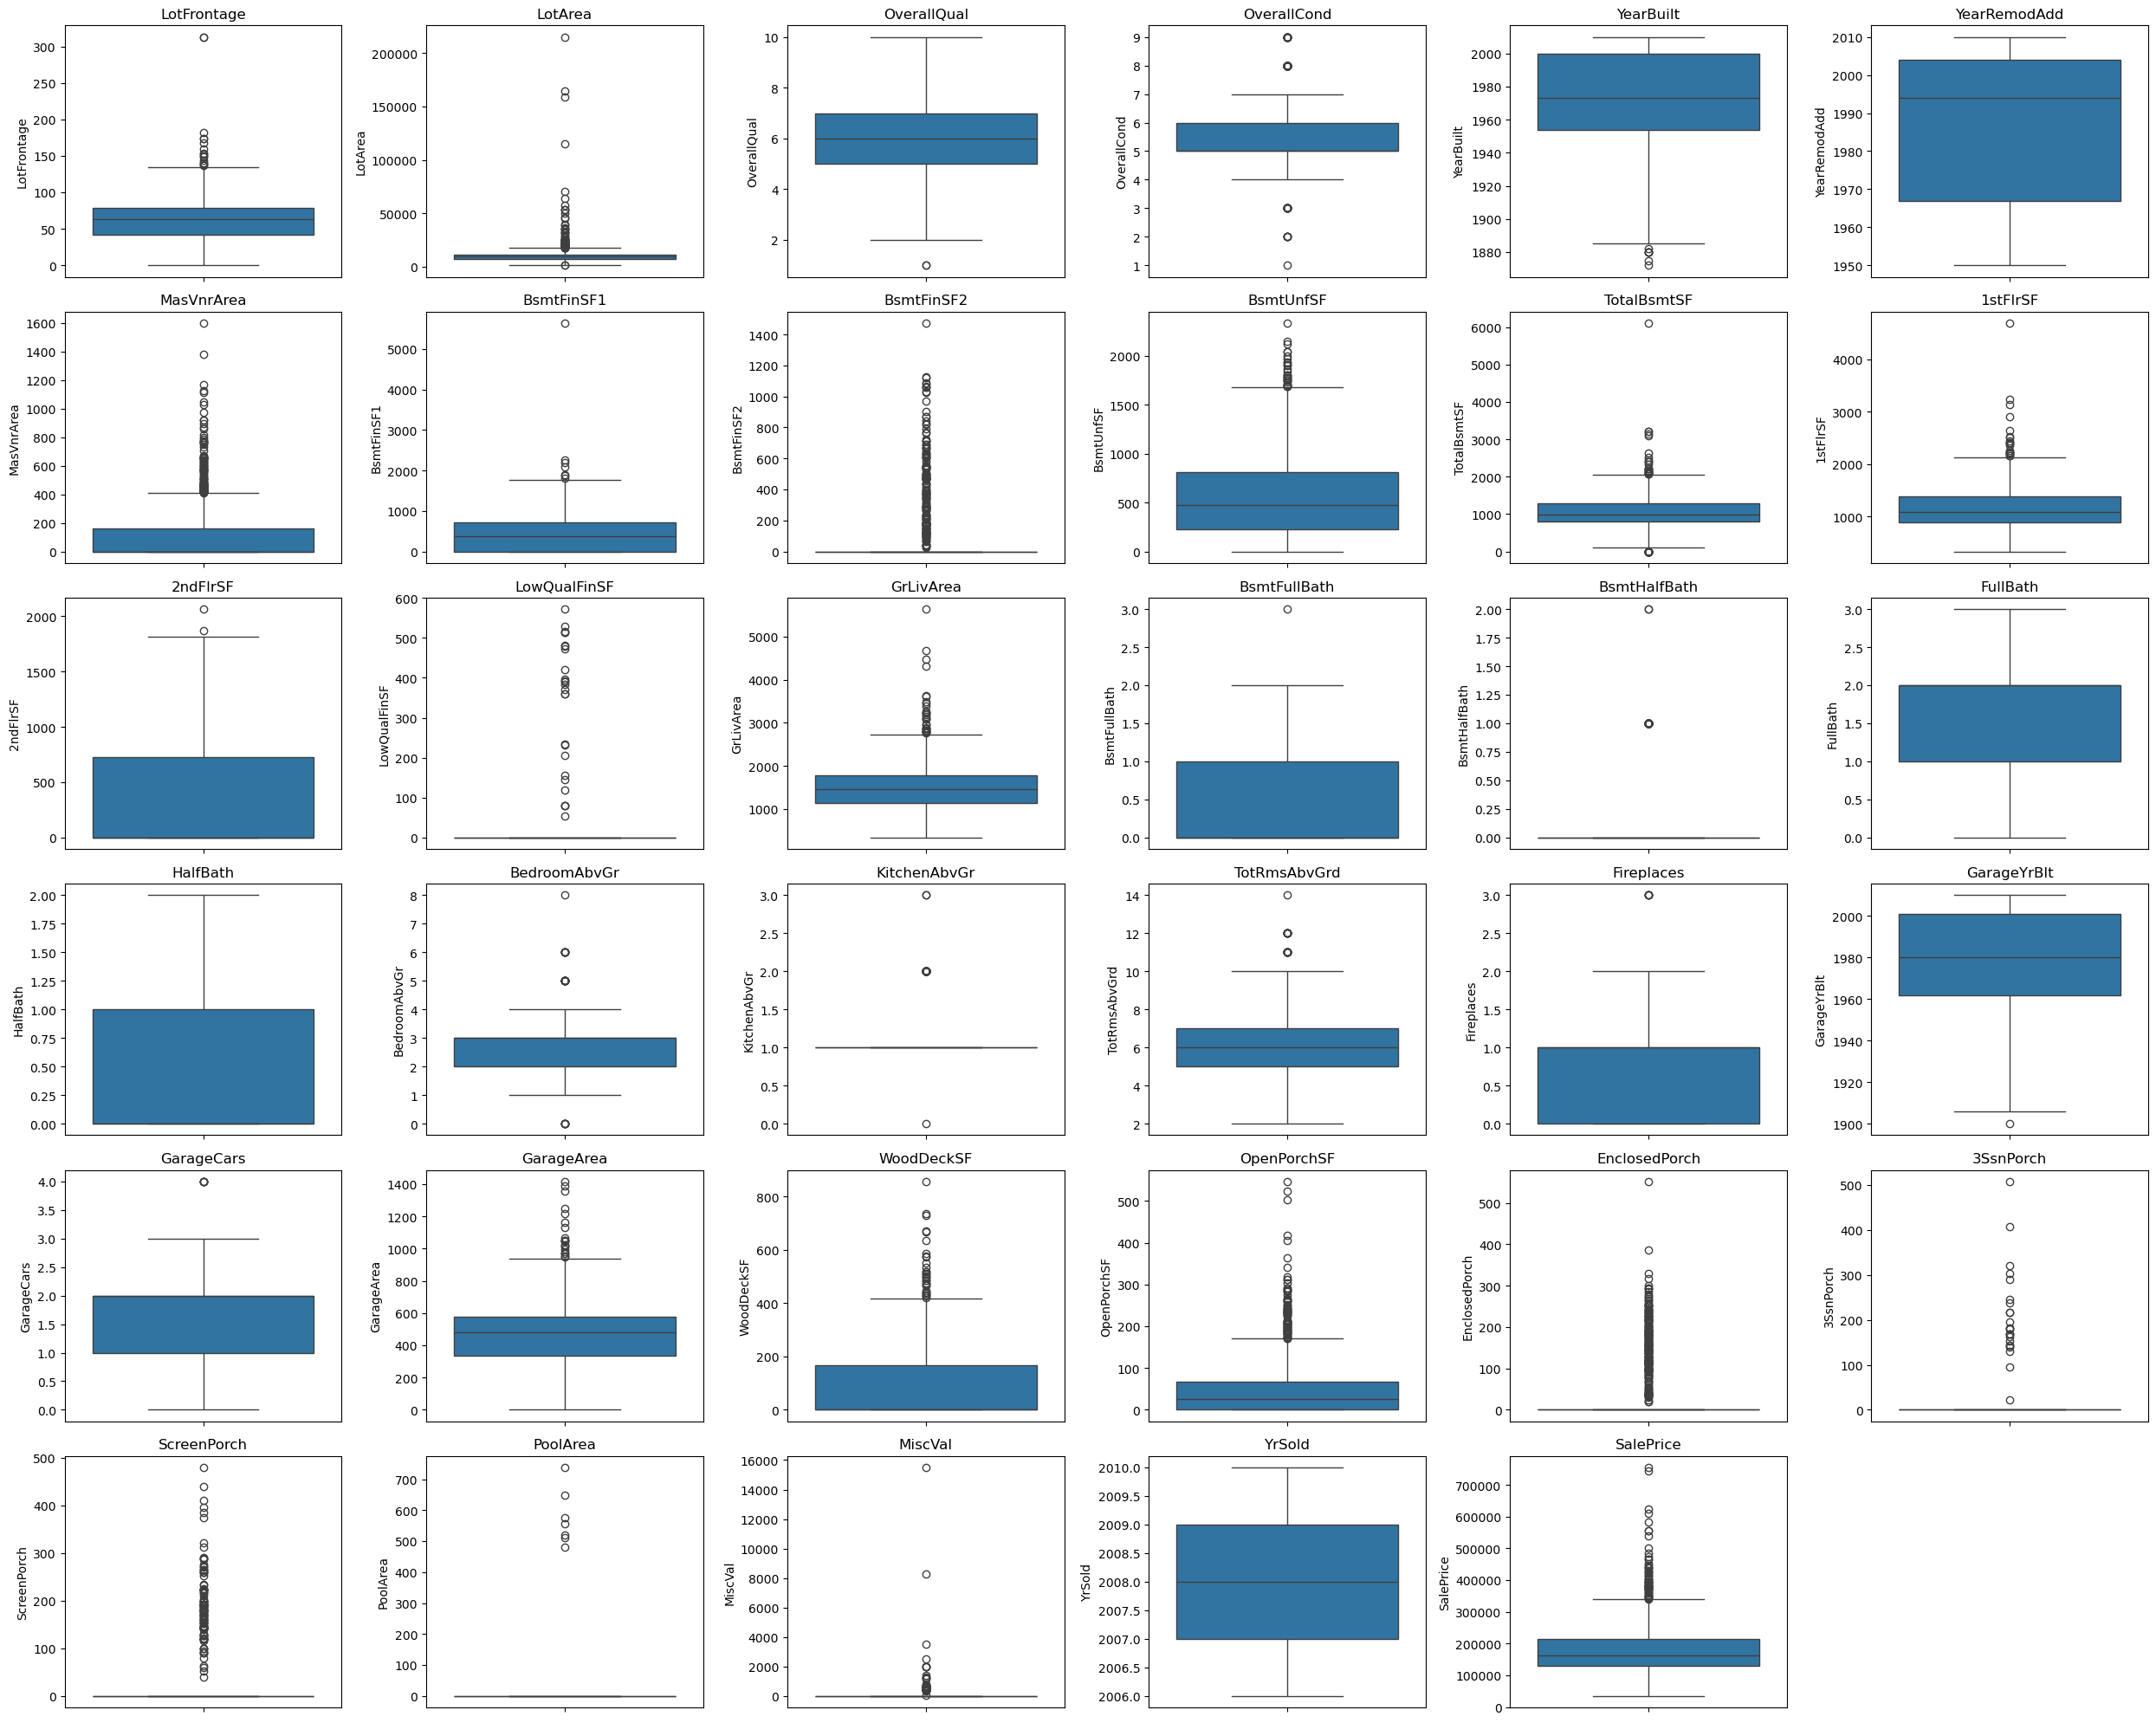

In [32]:
plt.figure(figsize = (25,20))
for i,col in enumerate(numerical_data,1):
    plt.subplot(6,6,i)
    sns.boxplot(y = df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

Inside => 1) Some of the data columns are containing outliers 

# Removing Outliers by using IQR (Inter Quartile Range)

In [35]:
# Here, IQR(Inter Quartile Range) Method is used to calculate outliers and capp with Min_value for Lower Value and Max_value for Upper Value.
for col in numerical_data:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    Min_value = Q1 - 1.5 * IQR
    Max_value = Q3 + 1.5 * IQR
  
    print(f"{col} = Lower Value: {round(Min_value,2)}, Upper Value: {round(Max_value,2)}")
    
# Capping to handle outliers with Max_value and Min_value. 
    df[col] = np.where(df[col] > Max_value,Max_value,
                        np.where(df[col] < Min_value, Min_value,df[col]))

LotFrontage = Lower Value: -13.5, Upper Value: 134.5
LotArea = Lower Value: 1481.5, Upper Value: 17673.5
OverallQual = Lower Value: 2.0, Upper Value: 10.0
OverallCond = Lower Value: 3.5, Upper Value: 7.5
YearBuilt = Lower Value: 1885.0, Upper Value: 2069.0
YearRemodAdd = Lower Value: 1911.5, Upper Value: 2059.5
MasVnrArea = Lower Value: -246.38, Upper Value: 410.62
BsmtFinSF1 = Lower Value: -1068.38, Upper Value: 1780.62
BsmtFinSF2 = Lower Value: 0.0, Upper Value: 0.0
BsmtUnfSF = Lower Value: -654.5, Upper Value: 1685.5
TotalBsmtSF = Lower Value: 42.0, Upper Value: 2052.0
1stFlrSF = Lower Value: 118.12, Upper Value: 2155.12
2ndFlrSF = Lower Value: -1092.0, Upper Value: 1820.0
LowQualFinSF = Lower Value: 0.0, Upper Value: 0.0
GrLivArea = Lower Value: 158.62, Upper Value: 2747.62
BsmtFullBath = Lower Value: -1.5, Upper Value: 2.5
BsmtHalfBath = Lower Value: 0.0, Upper Value: 0.0
FullBath = Lower Value: -0.5, Upper Value: 3.5
HalfBath = Lower Value: -1.5, Upper Value: 2.5
BedroomAbvGr = L

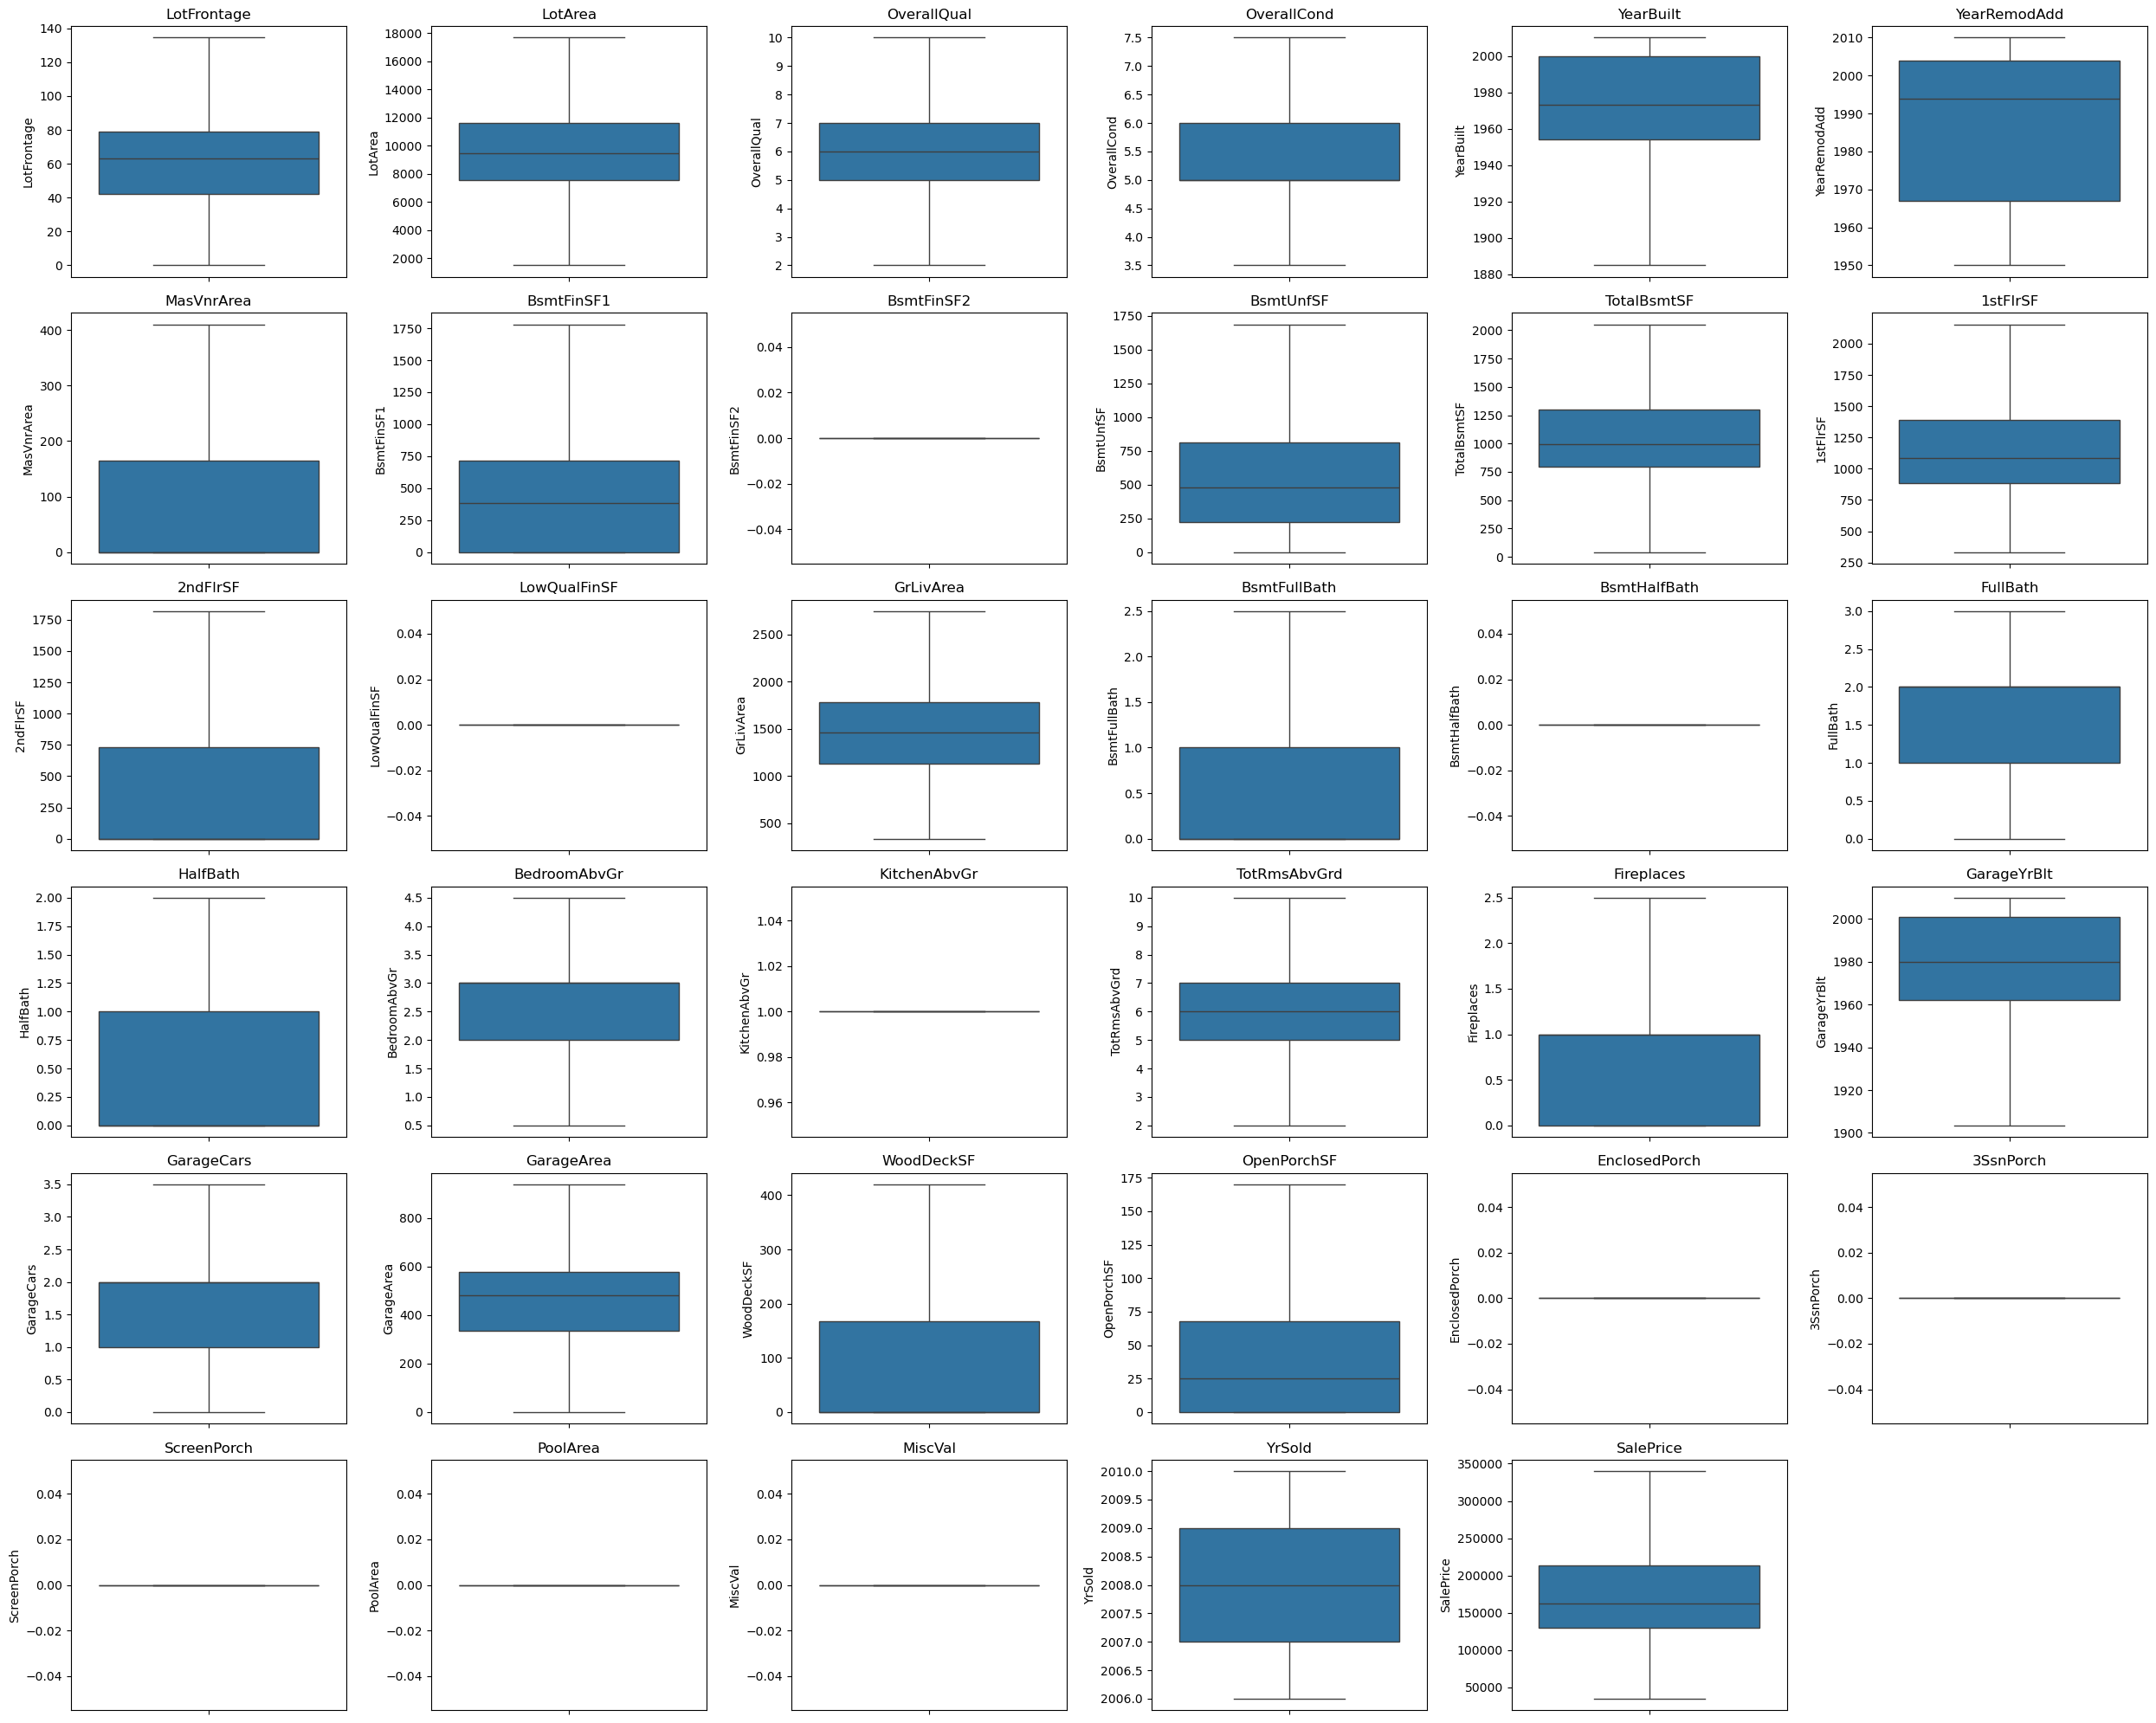

In [36]:
# After Capping Outliers with Min and Max value, Here Columns are checked Wheather it capped or not.
plt.figure(figsize = (25,20))
for i,col in enumerate(numerical_data,1):
    plt.subplot(6,6,i)
    sns.boxplot(y = df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

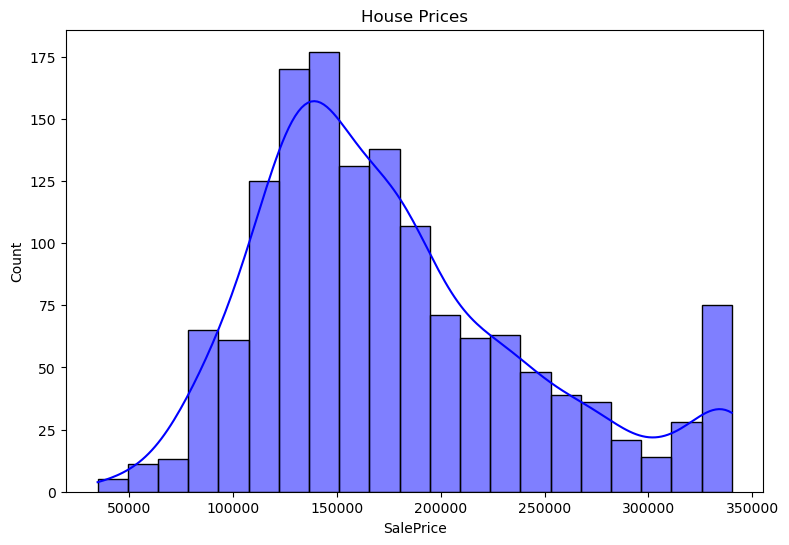

Skewness =  0.801961307169266


In [37]:
plt.figure(figsize = (9,6))
sns.histplot(df['SalePrice'], color= 'blue', kde = True)
plt.title('House Prices')
plt.show()
print('Skewness = ',skew(df['SalePrice']))

Observation = 
1) The highest Sale price Range ditribution between 80000 to 250000
2) The highest number of houses are sold between 80000 to 250000
3) The Sales Price data slitely positively skiw

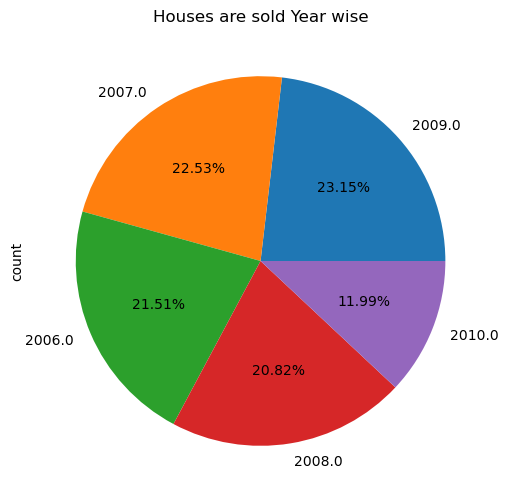

In [39]:
plt.figure(figsize = (9,6))
df['YrSold'].value_counts().plot(kind = 'pie', color = 'green', autopct = '%.2f%%')
plt.title('Houses are sold Year wise')
plt.show()

Observation 
1) The Highest number of houses are sold in 2009 near about 23.15% then 2007,2006 and 2008 respectively
2) The least number of houses are sold in 2010.

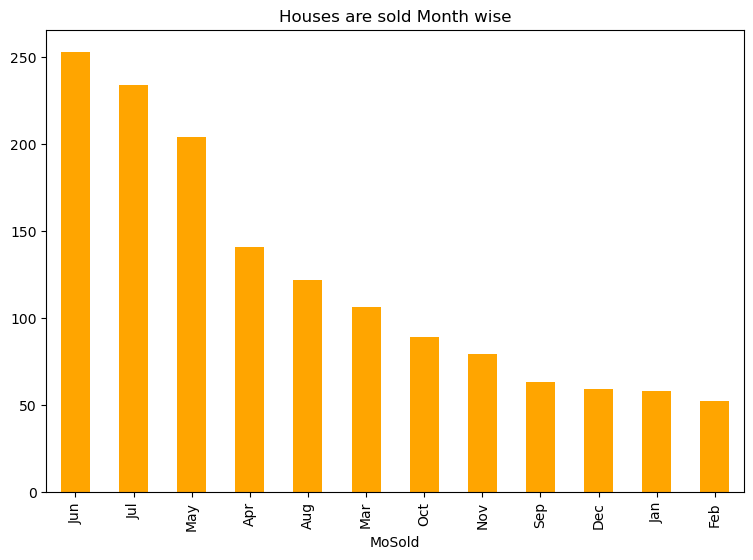

In [42]:
plt.figure(figsize = (9,6))
df['MoSold'].value_counts().plot(kind = 'bar', color = 'orange')
plt.title('Houses are sold Month wise')
plt.show()

Observation
1) The Highest number of houses are sold in the month of June, July, May and April
2) In Mansoon and Summer Season highest number of houses are sold
3) In Winter season least number of houses are sold.

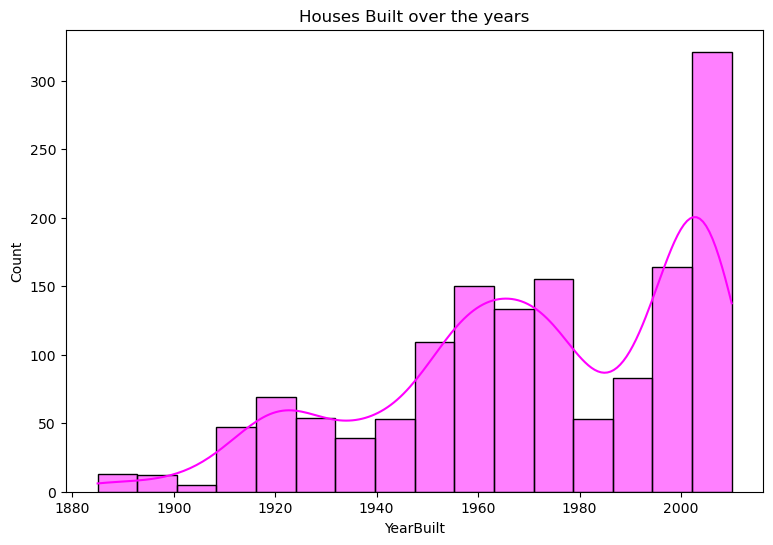

In [45]:
plt.figure(figsize = (9,6))
sns.histplot(df['YearBuilt'], color= 'magenta', kde = True)
plt.title('Houses Built over the years')
plt.show()

Observation
1) Maximum number of houses are built after 2000.
2) As a company started building a houses intially, the rate of costruction was slow but during the period of 1960 to 1970, the rate inceased.
3) In 1980 to 2000 again rate of construction was slow but then after it was drastically increased.
4) the data of houses building over the years is positively skiw, its tail is at left hand side.

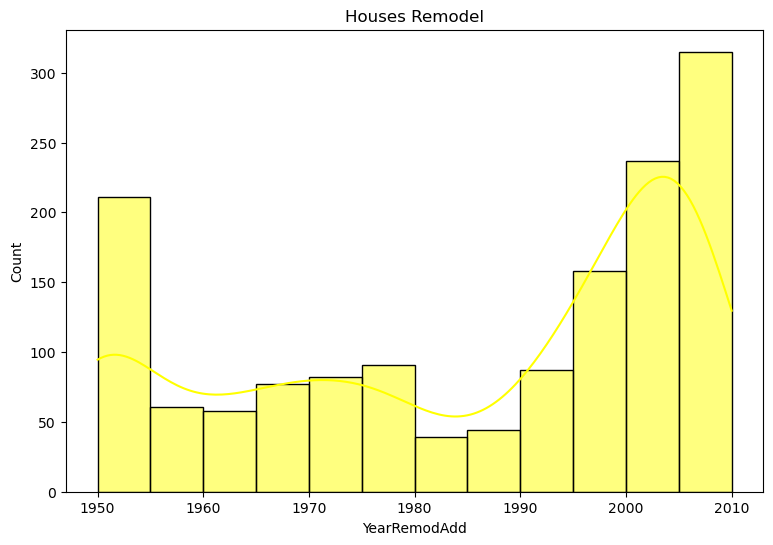

In [47]:
plt.figure(figsize = (9,6))
sns.histplot(df['YearRemodAdd'], color= 'yellow', kde = True)
plt.title('Houses Remodel')
plt.show()

Observation
1) The company has taken a task to remodel or addition in exsisting houses.
2) During the period of 2000 to 2010 the company has remodel or addition maximum number of houses.
3) During the period of 1980 to 1990 the rate of remodelling or additionn was slow like construction. 

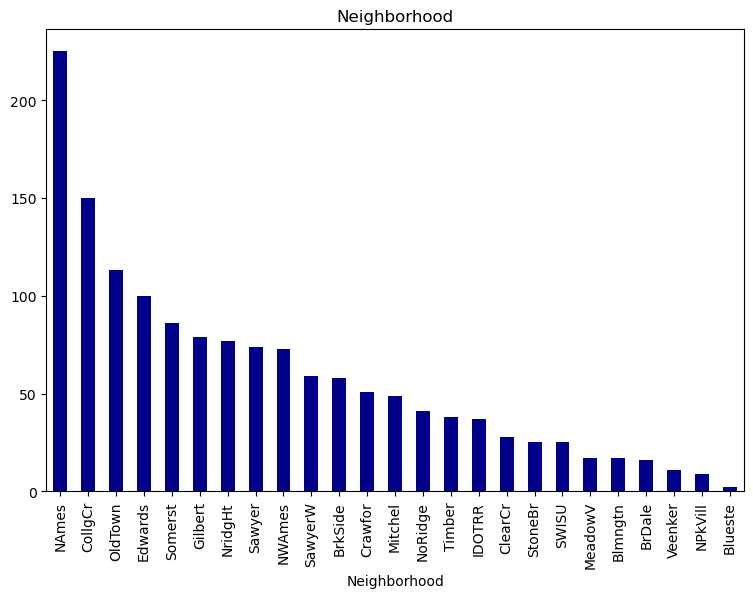

In [49]:
plt.figure(figsize = (9,6))
df['Neighborhood'].value_counts().plot(kind = 'bar', color = 'darkblue')
plt.title('Neighborhood')
plt.show()

Observation
1) This data physical locations is played very imp role for customers preferences.
2) Here peopel have given thye highest preferences to North Ames, College Creek and Old Town area.
3) Here Neighborhood columns can be influenced the SalePrice. 

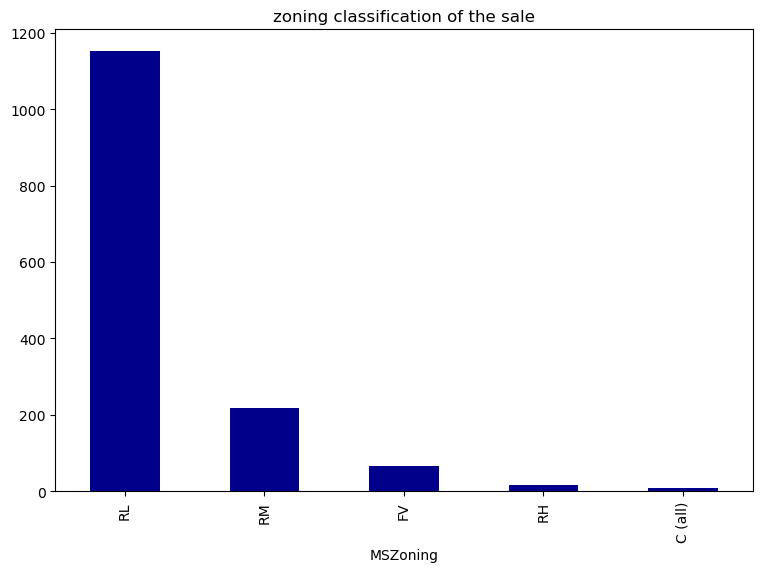

In [51]:
plt.figure(figsize = (9,6))
df['MSZoning'].value_counts().plot(kind = 'bar', color = 'darkblue')
plt.title('zoning classification of the sale')
plt.show()

Observation
1) RL is a Residential low-density area
2) Customers have given to most preferences to Residential low-density area houses.

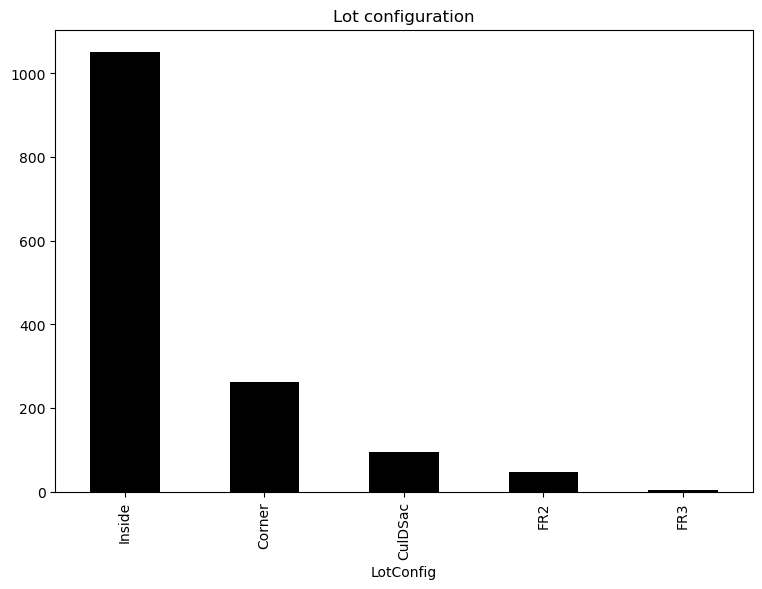

In [53]:
plt.figure(figsize = (9,6))
df['LotConfig'].value_counts().plot(kind = 'bar', color = 'black')
plt.title('Lot configuration')
plt.show()

Observation
1) While choosing a lot configuration people prefered inside lot configuration than corner or others.
2) lot configuration may also affect house prices.

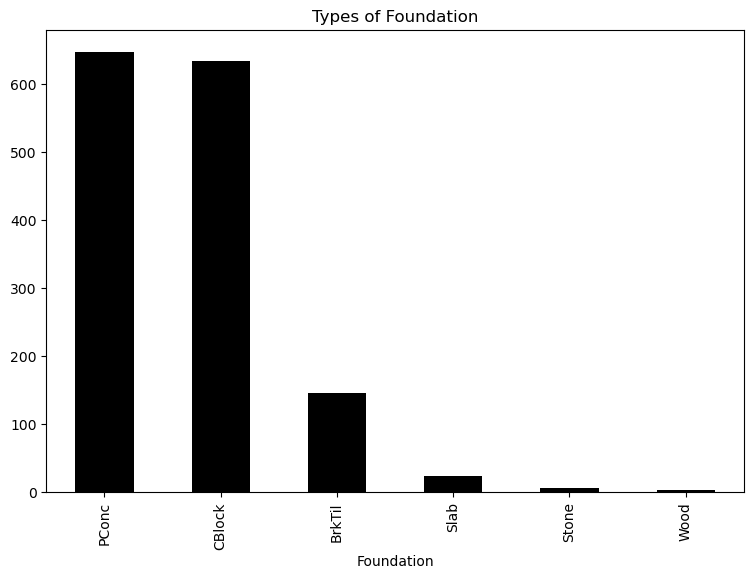

In [58]:
plt.figure(figsize = (9,6))
df['Foundation'].value_counts().plot(kind = 'bar', color = 'black')
plt.title('Types of Foundation')
plt.show()

Observation
1) foundation is fundamental part of any houses.
2) People have given the highest prefrences to concrete block foundation and poured concrete foundation
3) These two are considered strongest foundation for home.

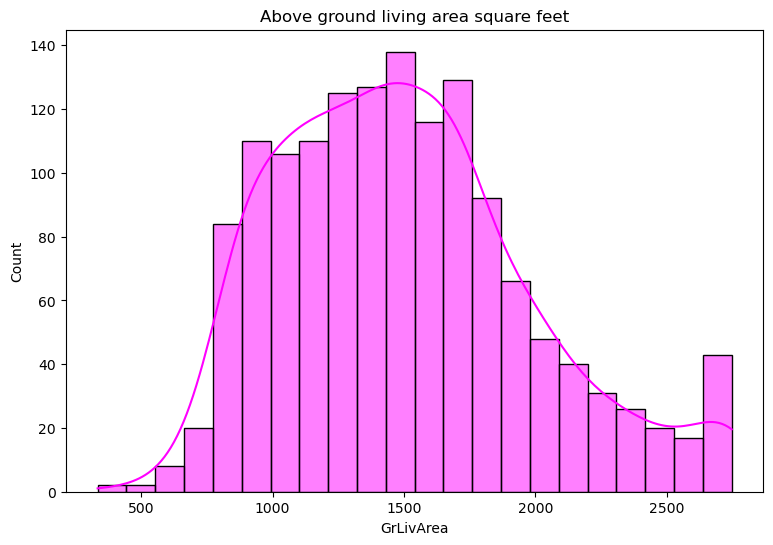

In [63]:
plt.figure(figsize = (9,6))
sns.histplot(df['GrLivArea'], color= 'magenta', kde = True)
plt.title('Above ground living area square feet')
plt.show()

Observation
1) Living area square feet maximum distribution between 700 to 2000 sqrft.
2) people maximum opted living area between 700 to 2000 sqrft.

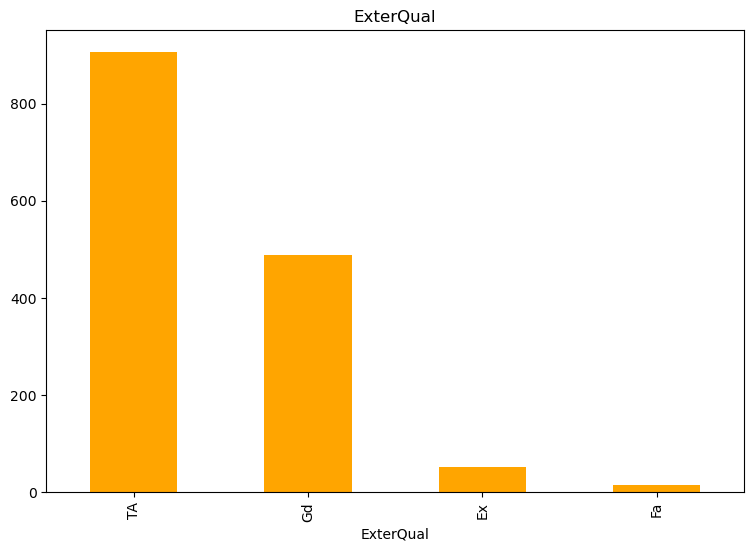

In [68]:
plt.figure(figsize = (9,6))
df['ExterQual'].value_counts().plot(kind = 'bar', color = 'orange')
plt.title('ExterQual')
plt.show()

Observation
1) The Average/Typical quality of the material on the exterior is highest number of counts
2) Good quality of the material on the exterior is come on the second number of counts

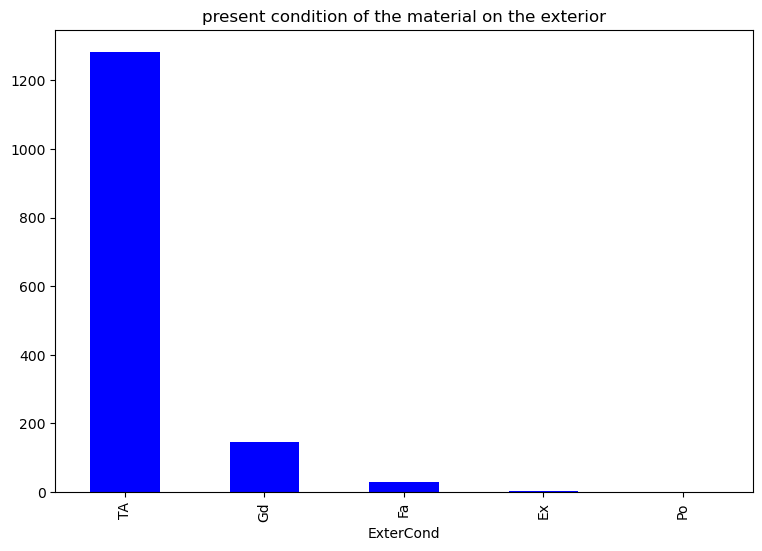

In [71]:
plt.figure(figsize = (9,6))
df['ExterCond'].value_counts().plot(kind = 'bar', color = 'Blue')
plt.title('present condition of the material on the exterior')
plt.show()

Observation
1) The Average/Typical present condition of the material on the exterior is highest number of counts
2) Good condition of the material on the exterior is come on the second number of count.

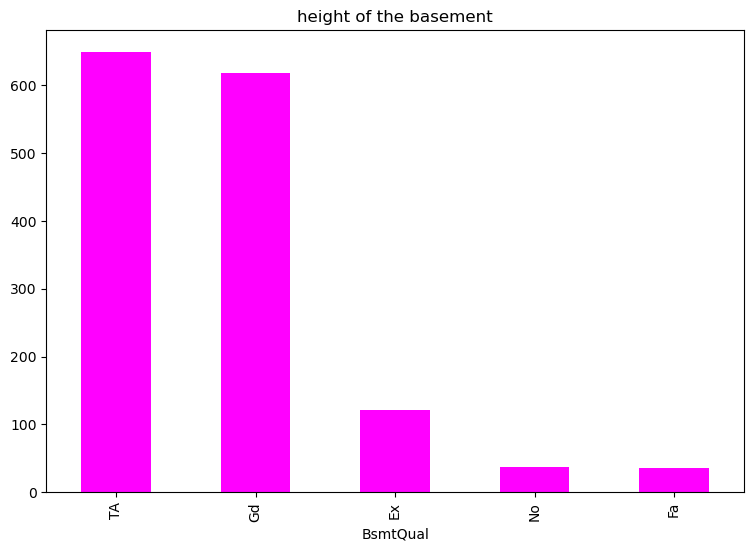

In [76]:
plt.figure(figsize = (9,6))
df['BsmtQual'].value_counts().plot(kind = 'bar', color = 'magenta')
plt.title('height of the basement')
plt.show()

Observation
1) Most basements have Typical (80-89 inches) to 90-99 inches.
2) 80-89 inches to 90-99 inches height of the basements contribute to higher house prices.

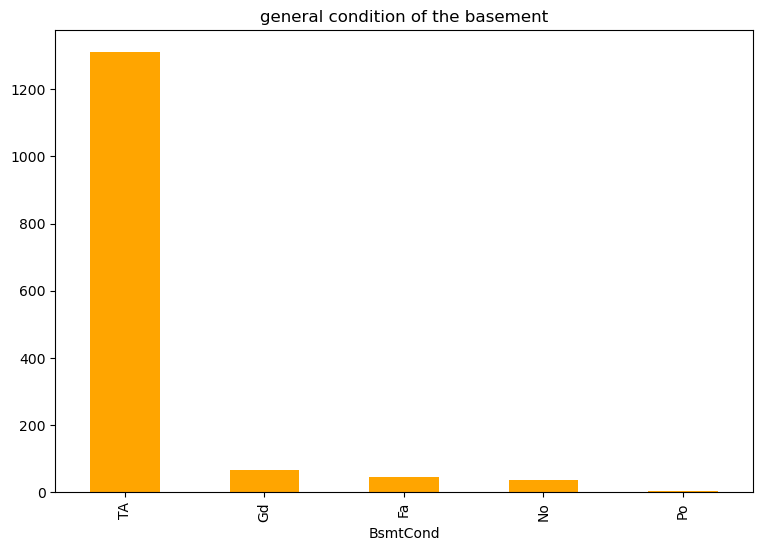

In [79]:
plt.figure(figsize = (9,6))
df['BsmtCond'].value_counts().plot(kind = 'bar', color = 'orange')
plt.title('general condition of the basement')
plt.show()

Observation
1) Majority of basements are in Average (TA) or Good (Gd) condition.
2) Poor basement conditions are uncommon but may reduce property value.

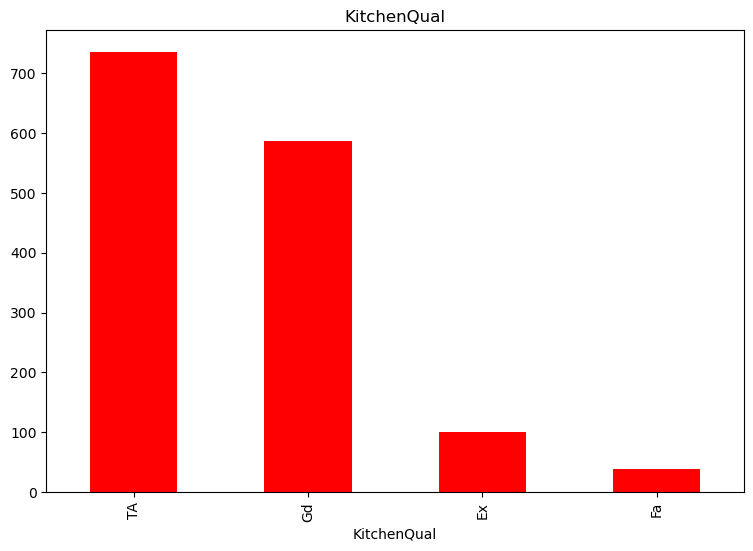

In [82]:
plt.figure(figsize = (9,6))
df['KitchenQual'].value_counts().plot(kind = 'bar', color = 'red')
plt.title('KitchenQual')
plt.show()

Observation
1) Most homes have Average(TA), Good (Gd) and Excellent (Ex) kitchen quality.
2) Kitchen quality significantly influences home value

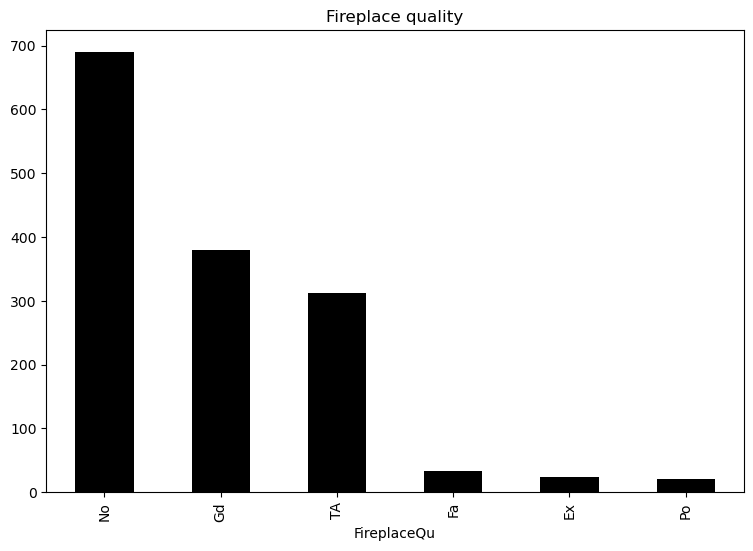

In [85]:
plt.figure(figsize = (9,6))
df['FireplaceQu'].value_counts().plot(kind = 'bar', color = 'black')
plt.title('Fireplace quality')
plt.show()

Observation
1) Many houses lack fireplaces, but those with high-quality fireplaces add value.
2) Fireplaces are a luxury feature, enhancing desirability.

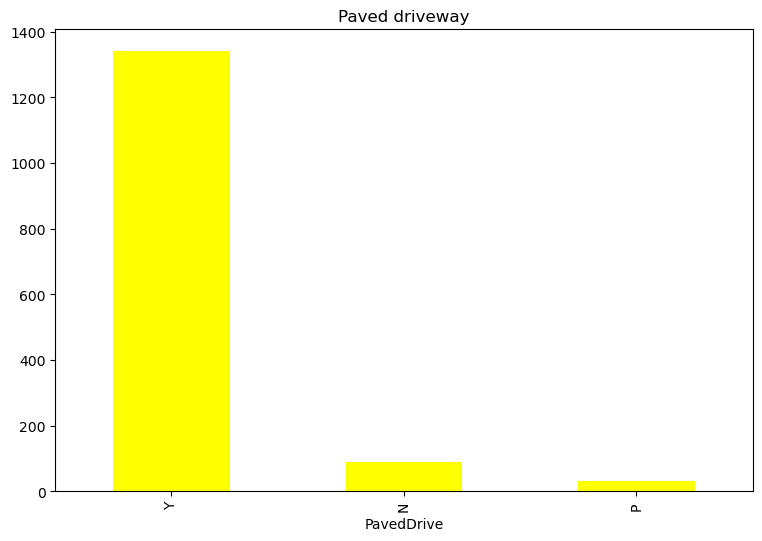

In [88]:
plt.figure(figsize = (9,6))
df['PavedDrive'].value_counts().plot(kind = 'bar', color = 'yellow')
plt.title('Paved driveway')
plt.show()

Observation
1) Most homes have a paved driveway (Y).
2) Non-paved driveways are less common and could indicate older homes.

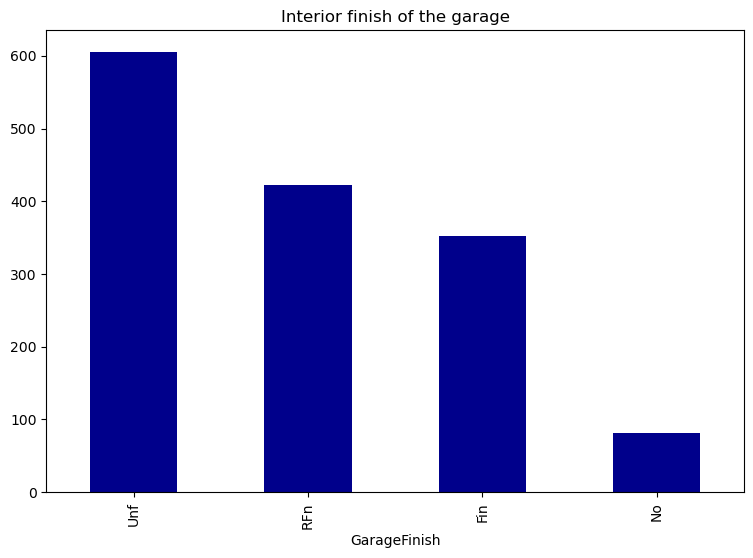

In [91]:
plt.figure(figsize = (9,6))
df['GarageFinish'].value_counts().plot(kind = 'bar', color = 'darkblue')
plt.title('Interior finish of the garage')
plt.show()

Observation
1) Most garages are unfinished (Unf) and rough finished (RFn).
2) Finished garages increase home value and buyer appeal.

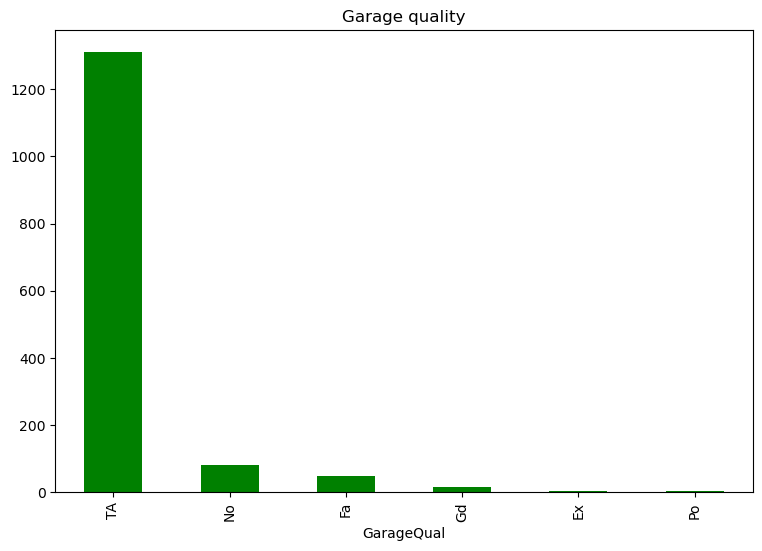

In [94]:
plt.figure(figsize = (9,6))
df['GarageQual'].value_counts().plot(kind = 'bar', color = 'green')
plt.title('Garage quality')
plt.show()

Observation
1) Majority of garages have Average (TA) quality.
2) Poor garage quality is rare, suggesting maintenance is prioritized. 

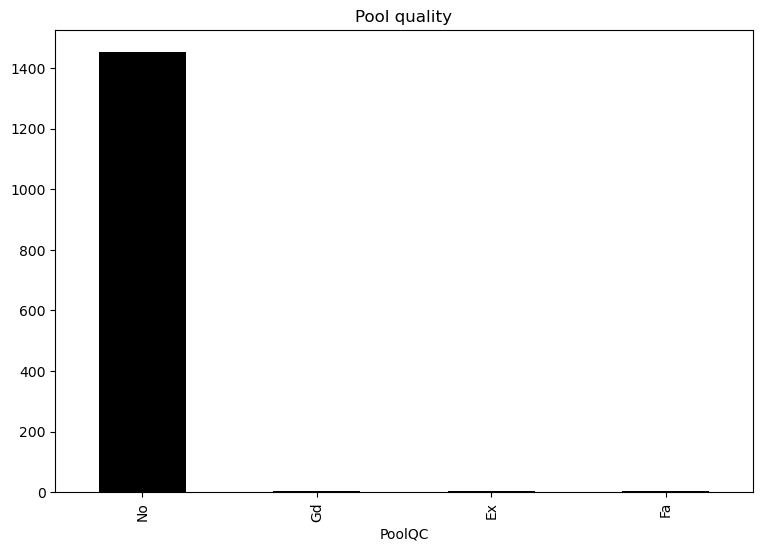

In [97]:
plt.figure(figsize = (9,6))
df['PoolQC'].value_counts().plot(kind = 'bar', color = 'black')
plt.title('Pool quality')
plt.show()

Observation
1) No houses have pools, making it a rare feature.
2) Pools are an exclusive feature, mostly found in luxury homes.

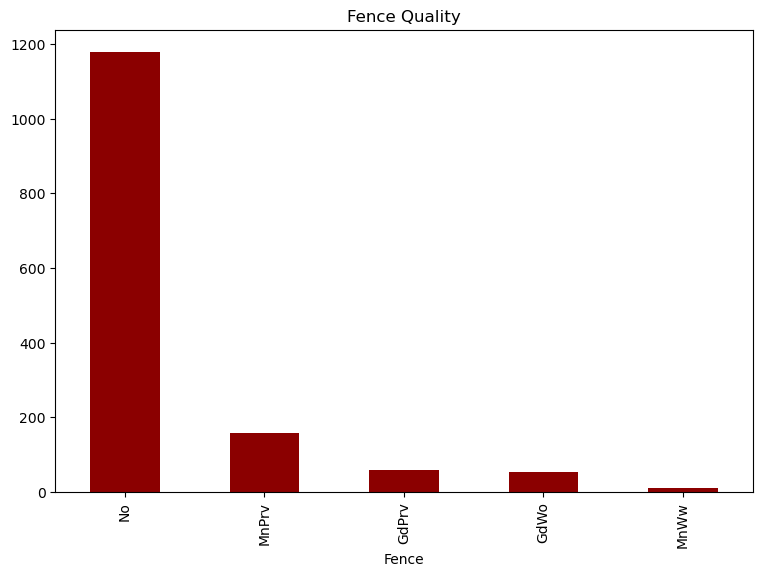

In [100]:
plt.figure(figsize = (9,6))
df['Fence'].value_counts().plot(kind = 'bar', color = 'darkred')
plt.title('Fence Quality')
plt.show()

Observation
1) Many houses lack fences, but those with them often have Average (MnPrv) or Good (GdPrv) privacy.
2) Fences are more common in family-friendly properties

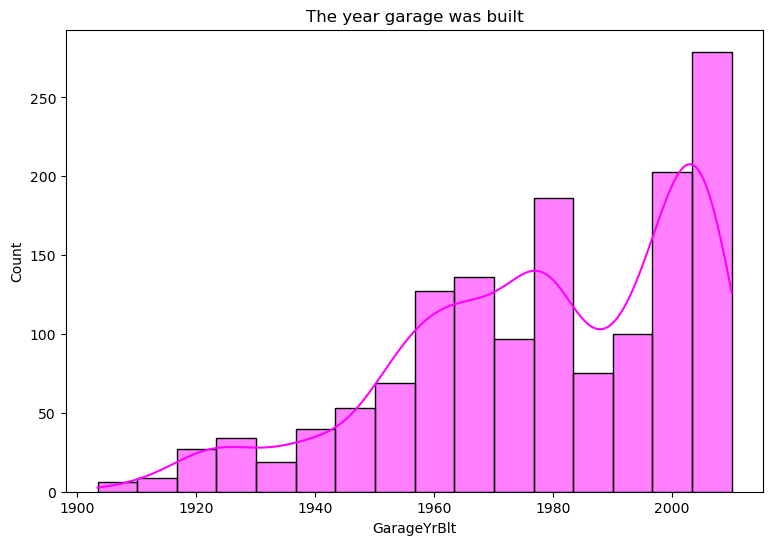

In [103]:
plt.figure(figsize = (9,6))
sns.histplot(df['GarageYrBlt'], color= 'magenta', kde = True)
plt.title('The year garage was built')
plt.show()

Observation
1) Many garages were built alongside the house, matching YearBuilt.
2) Newer garages may indicate better condition and functionality.

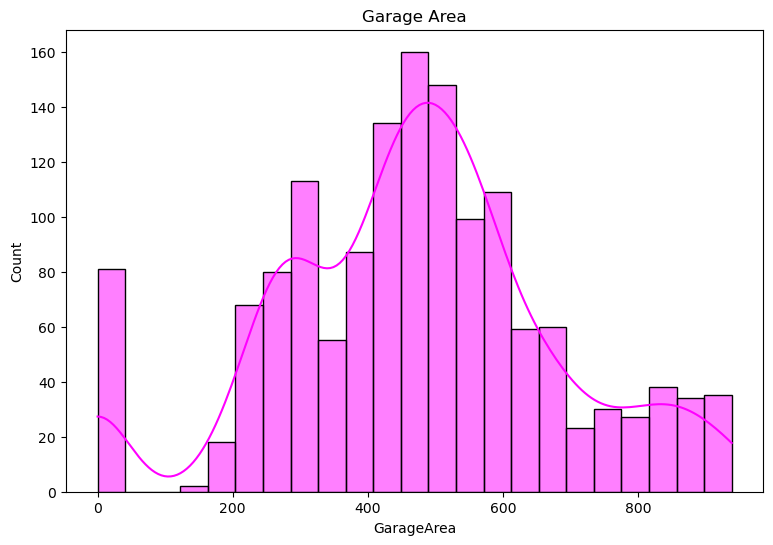

In [106]:
plt.figure(figsize = (9,6))
sns.histplot(df['GarageArea'], color= 'magenta', kde = True)
plt.title('Garage Area')
plt.show()

Observation
1) Garage sizes vary significantly, but most fit between 200 to 700 square feet.
2) Bigger garages increase storage and appeal.

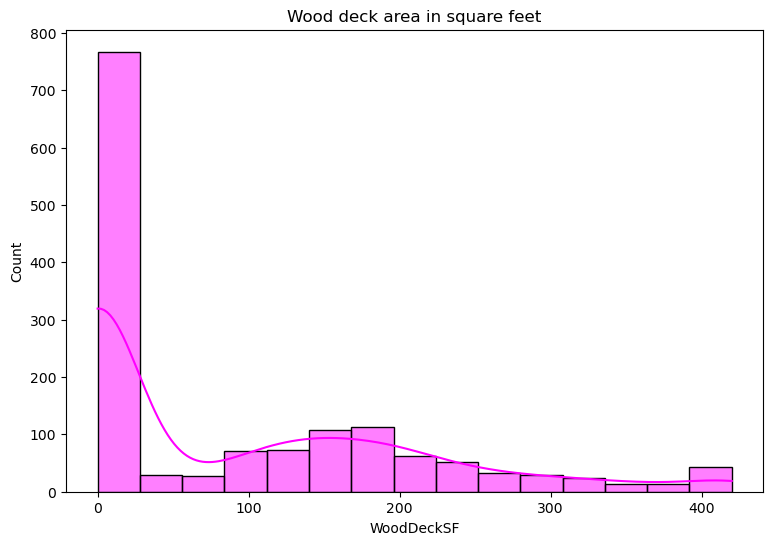

In [109]:
plt.figure(figsize = (9,6))
sns.histplot(df['WoodDeckSF'], color= 'magenta', kde = True)
plt.title('Wood deck area in square feet')
plt.show()

Observation
1) Many houses lack a deck, but some have large outdoor spaces.
2) Decks may improve outdoor living and property appeal

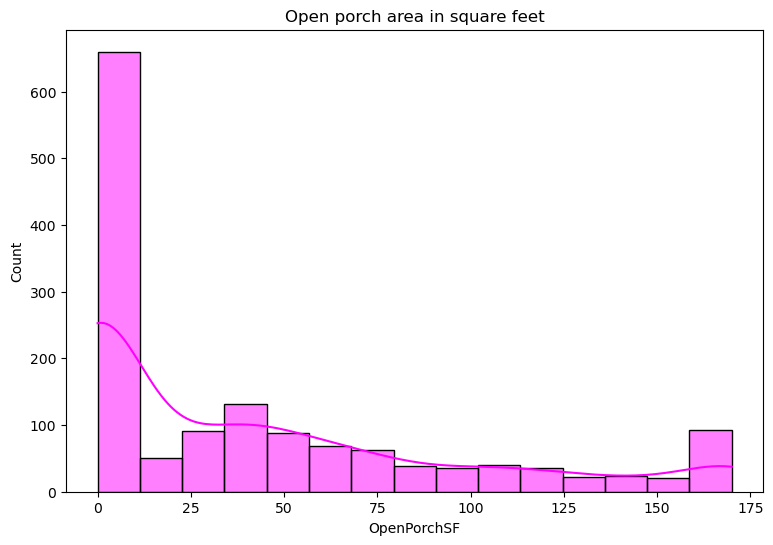

In [112]:
plt.figure(figsize = (9,6))
sns.histplot(df['OpenPorchSF'], color= 'magenta', kde = True)
plt.title('Open porch area in square feet')
plt.show()

Observation
1) Open porches are common but vary in size.
2) Larger porches add curb appeal and outdoor relaxation space.

# Bivariant Analysis

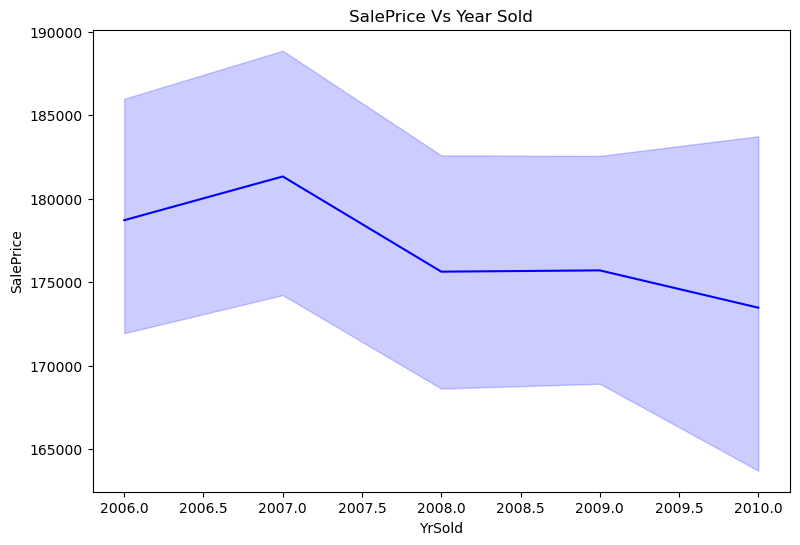

In [116]:
plt.figure(figsize = (9,6))
sns.lineplot(data = df, x = 'YrSold', y = 'SalePrice',color='blue')
plt.title('SalePrice Vs Year Sold')
plt.show()

Observation
1) By Analysing the relationship between years sold and Sales price, here we come to know that by passing the years prices of houses are come down.
2) There is inverse relationship between house prices and years sold.

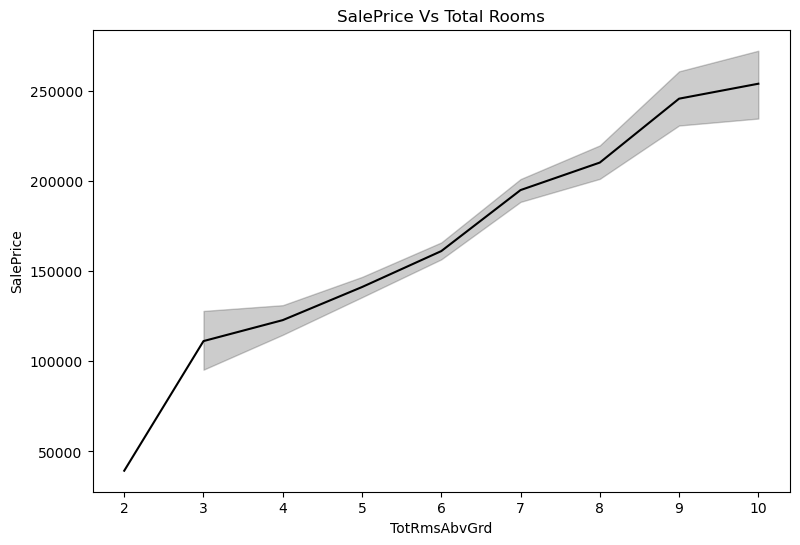

In [119]:
plt.figure(figsize = (9,6))
sns.lineplot(data = df, x = 'TotRmsAbvGrd', y = 'SalePrice',color='Black')
plt.title('SalePrice Vs Total Rooms')
plt.show()

Observation
1) More rooms generally mean higher prices.
2) Here is direct relationship between Total Rooms and sales Prices.

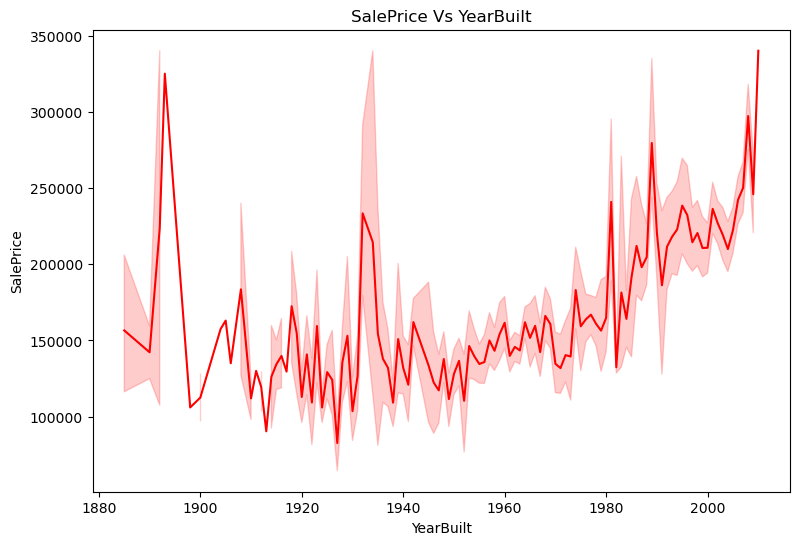

In [122]:
plt.figure(figsize = (9,6))
sns.lineplot(data = df, x = 'YearBuilt', y = 'SalePrice',color='red')
plt.title('SalePrice Vs YearBuilt')
plt.show()

Observations
1) Newer homes generally cost more than older ones.
2) Some very old houses still sell at a high price, likely due to renovations or historical value.

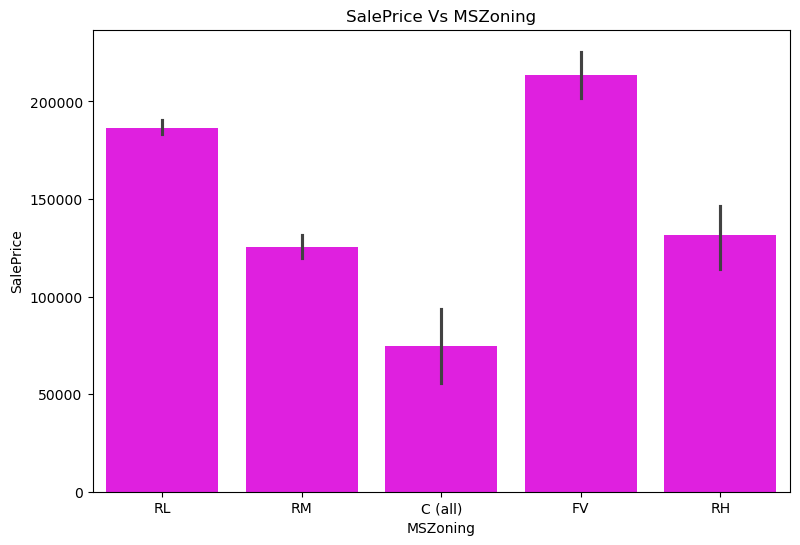

In [124]:
plt.figure(figsize = (9,6))
sns.barplot(data = df, x = 'MSZoning', y = 'SalePrice',color='Magenta')
plt.title('SalePrice Vs MSZoning')
plt.show()

Observation
1) The Prices of (FV) Floating Village Residential is higher among all zone.
2) The Residential Low-Density(RL) houses are also higher prices after FV.

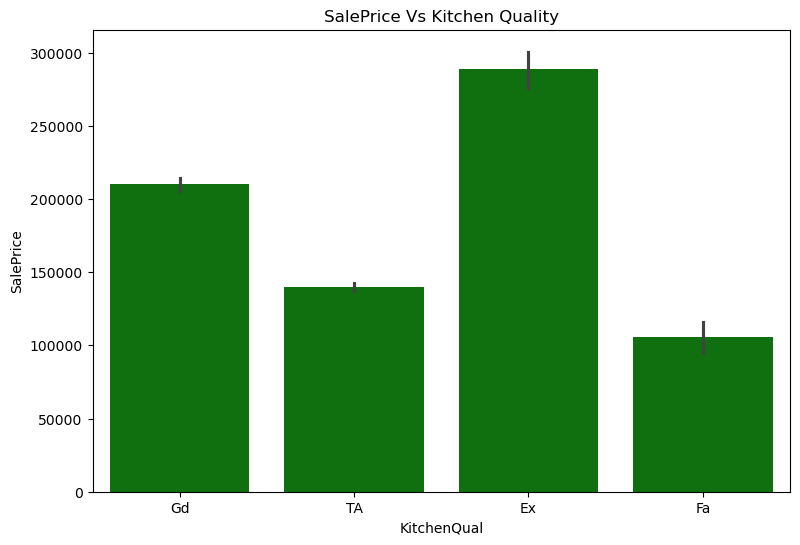

In [127]:
plt.figure(figsize = (9,6))
sns.barplot(data = df, x = 'KitchenQual', y = 'SalePrice',color='green')
plt.title('SalePrice Vs Kitchen Quality')
plt.show()

Observation
1) Strong positive correlation with SalePrice— Kitchen Quality leads to higher prices.
2) More expensive houses usually have a good Kitchen Quality like Excellent(Ex) and Good(Gd)

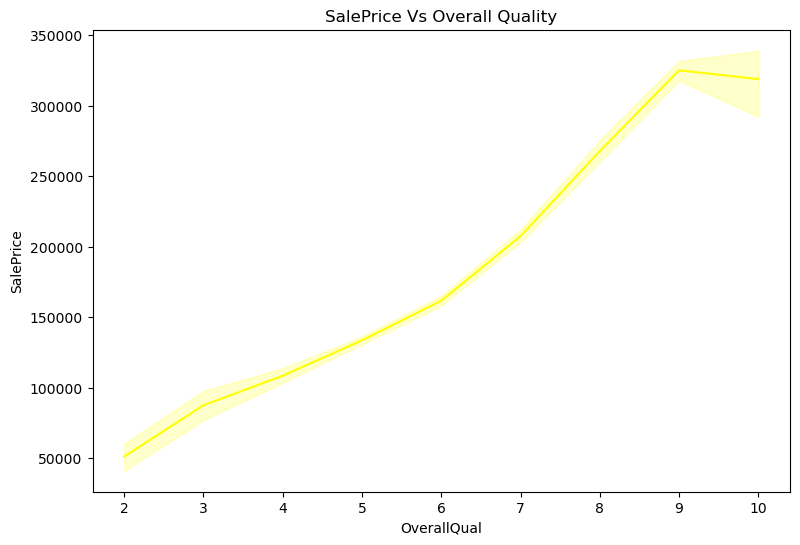

In [131]:
plt.figure(figsize = (9,6))
sns.lineplot(data = df, x = 'OverallQual', y = 'SalePrice',color='yellow')
plt.title('SalePrice Vs Overall Quality')
plt.show()

Observation
1) strong positive correlation with SalePrice—higher quality leads to higher prices.
2) More expensive houses usually have an OverallQual of 8 or above

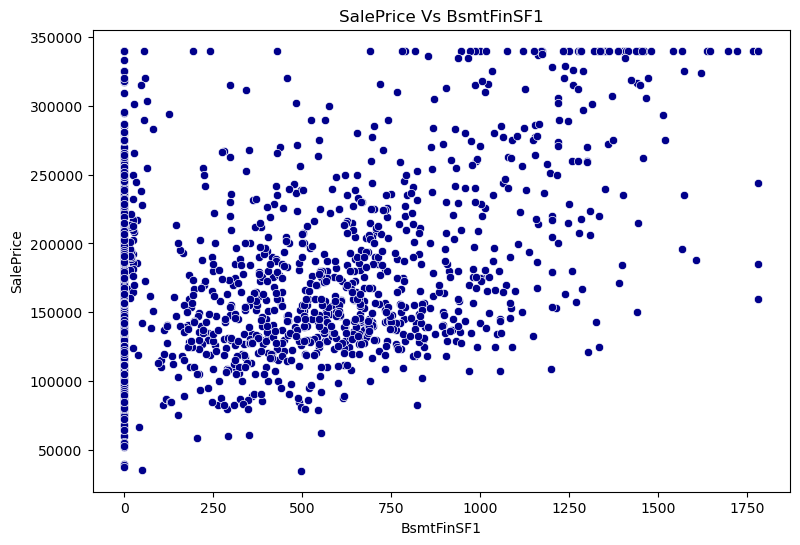

In [134]:
plt.figure(figsize = (9,6))
sns.scatterplot(data = df, x = 'BsmtFinSF1', y = 'SalePrice',color='darkblue')
plt.title('SalePrice Vs BsmtFinSF1')
plt.show()

Observation
1) Larger finished basements increase home price.
2) Many homes with 0 finished basement still have high prices, meaning basement finishing is not always necessary for value.


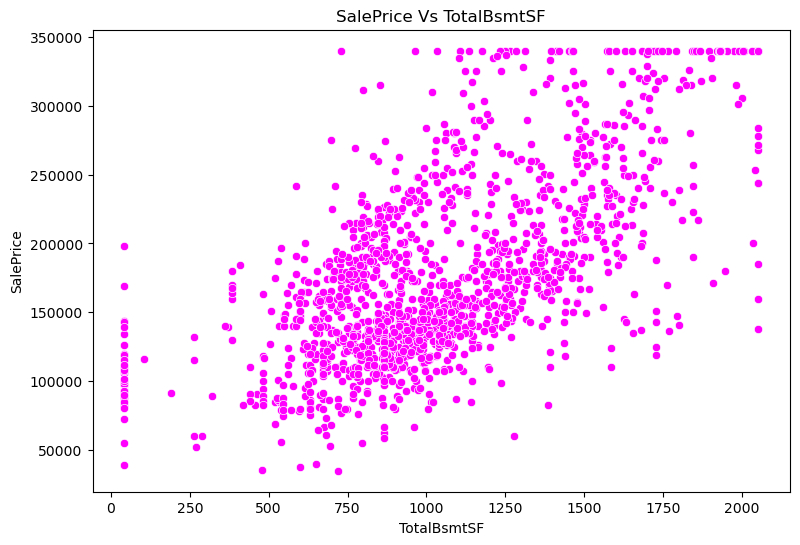

In [137]:
plt.figure(figsize = (9,6))
sns.scatterplot(data = df, x = 'TotalBsmtSF', y = 'SalePrice', color='Magenta')
plt.title('SalePrice Vs TotalBsmtSF')
plt.show()

Observation
1) Linear relationship More basement space = higher price.
2) Some very large basements do not always result in higher prices, suggesting diminishing returns.

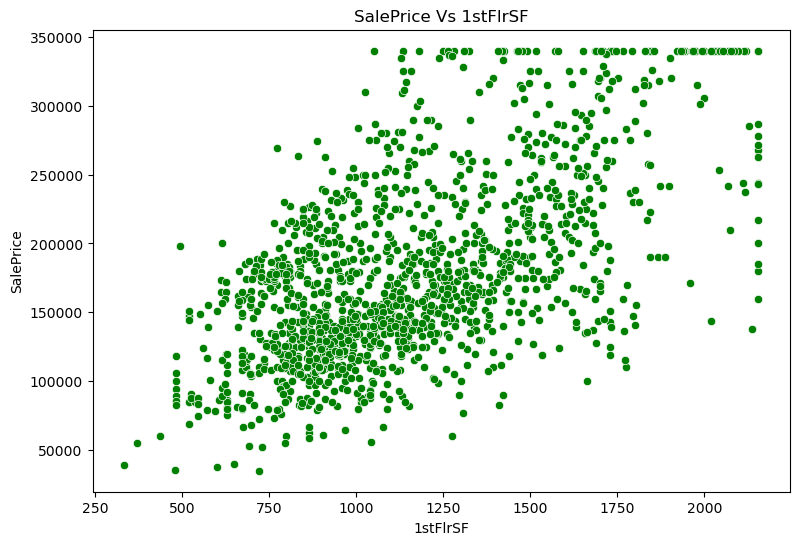

In [140]:
plt.figure(figsize = (9,6))
sns.scatterplot(data = df, x = '1stFlrSF', y = 'SalePrice', color='green')
plt.title('SalePrice Vs 1stFlrSF')
plt.show()

Observation
1) A positive trend—larger first floors correlate with higher prices.
2) Some homes with moderate 1stFlrSF have very high prices, possibly due to location or luxury upgrades.

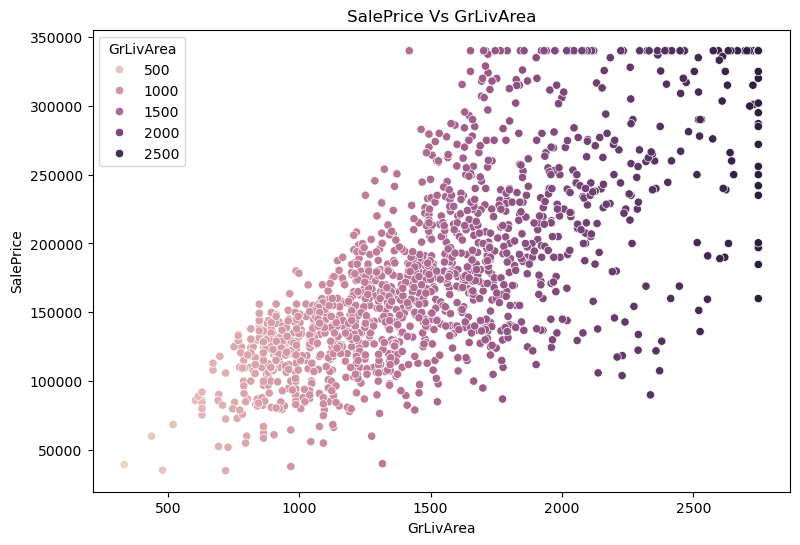

In [143]:
plt.figure(figsize = (9,6))
sns.scatterplot(data = df, x = 'GrLivArea', y = 'SalePrice', hue = 'GrLivArea', color='Blue')
plt.title('SalePrice Vs GrLivArea')
plt.show()

Observation
1) Strong positive correlation. Larger homes fetch higher prices.
2) There is positive corelation between living area square feet and houses price.

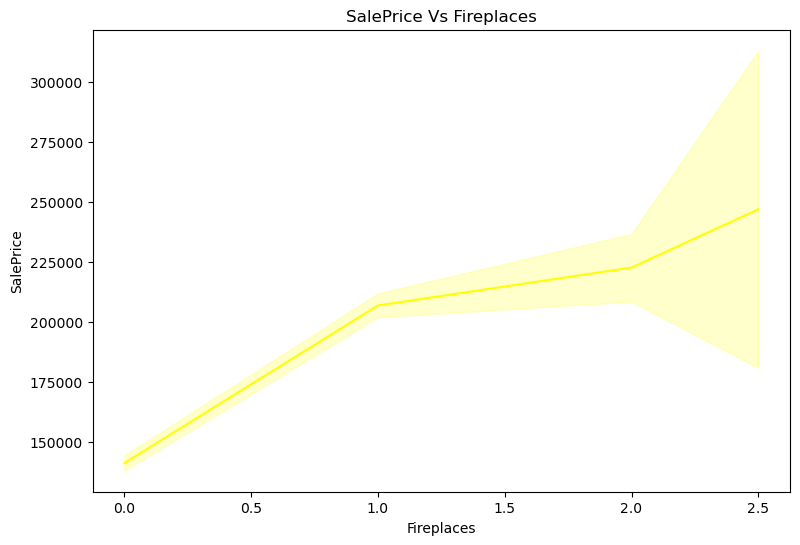

In [146]:
plt.figure(figsize = (9,6))
sns.lineplot(data = df, x = 'Fireplaces', y = 'SalePrice', color='Yellow')
plt.title('SalePrice Vs Fireplaces')
plt.show()

Observation
1) Houses with at least one fireplace tend to have higher prices.
2) Luxury homes often feature multiple fireplaces.

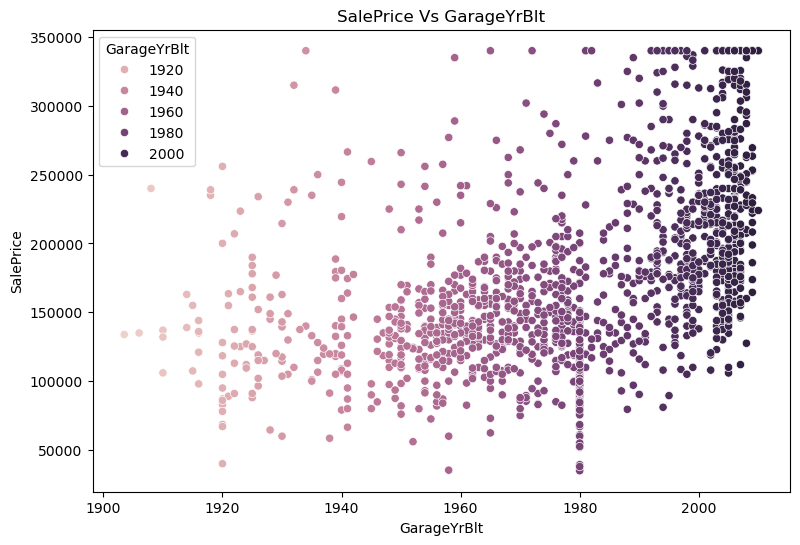

In [149]:
plt.figure(figsize = (9,6))
sns.scatterplot(data = df, x = 'GarageYrBlt', y = 'SalePrice', hue = 'GarageYrBlt',  color='Black')
plt.title('SalePrice Vs GarageYrBlt')
plt.show()

Observation
1) Newer garages correlate with higher home prices.
2) Older garages (built before 1950) have more variability in pricing.

# Multivariant Analysis

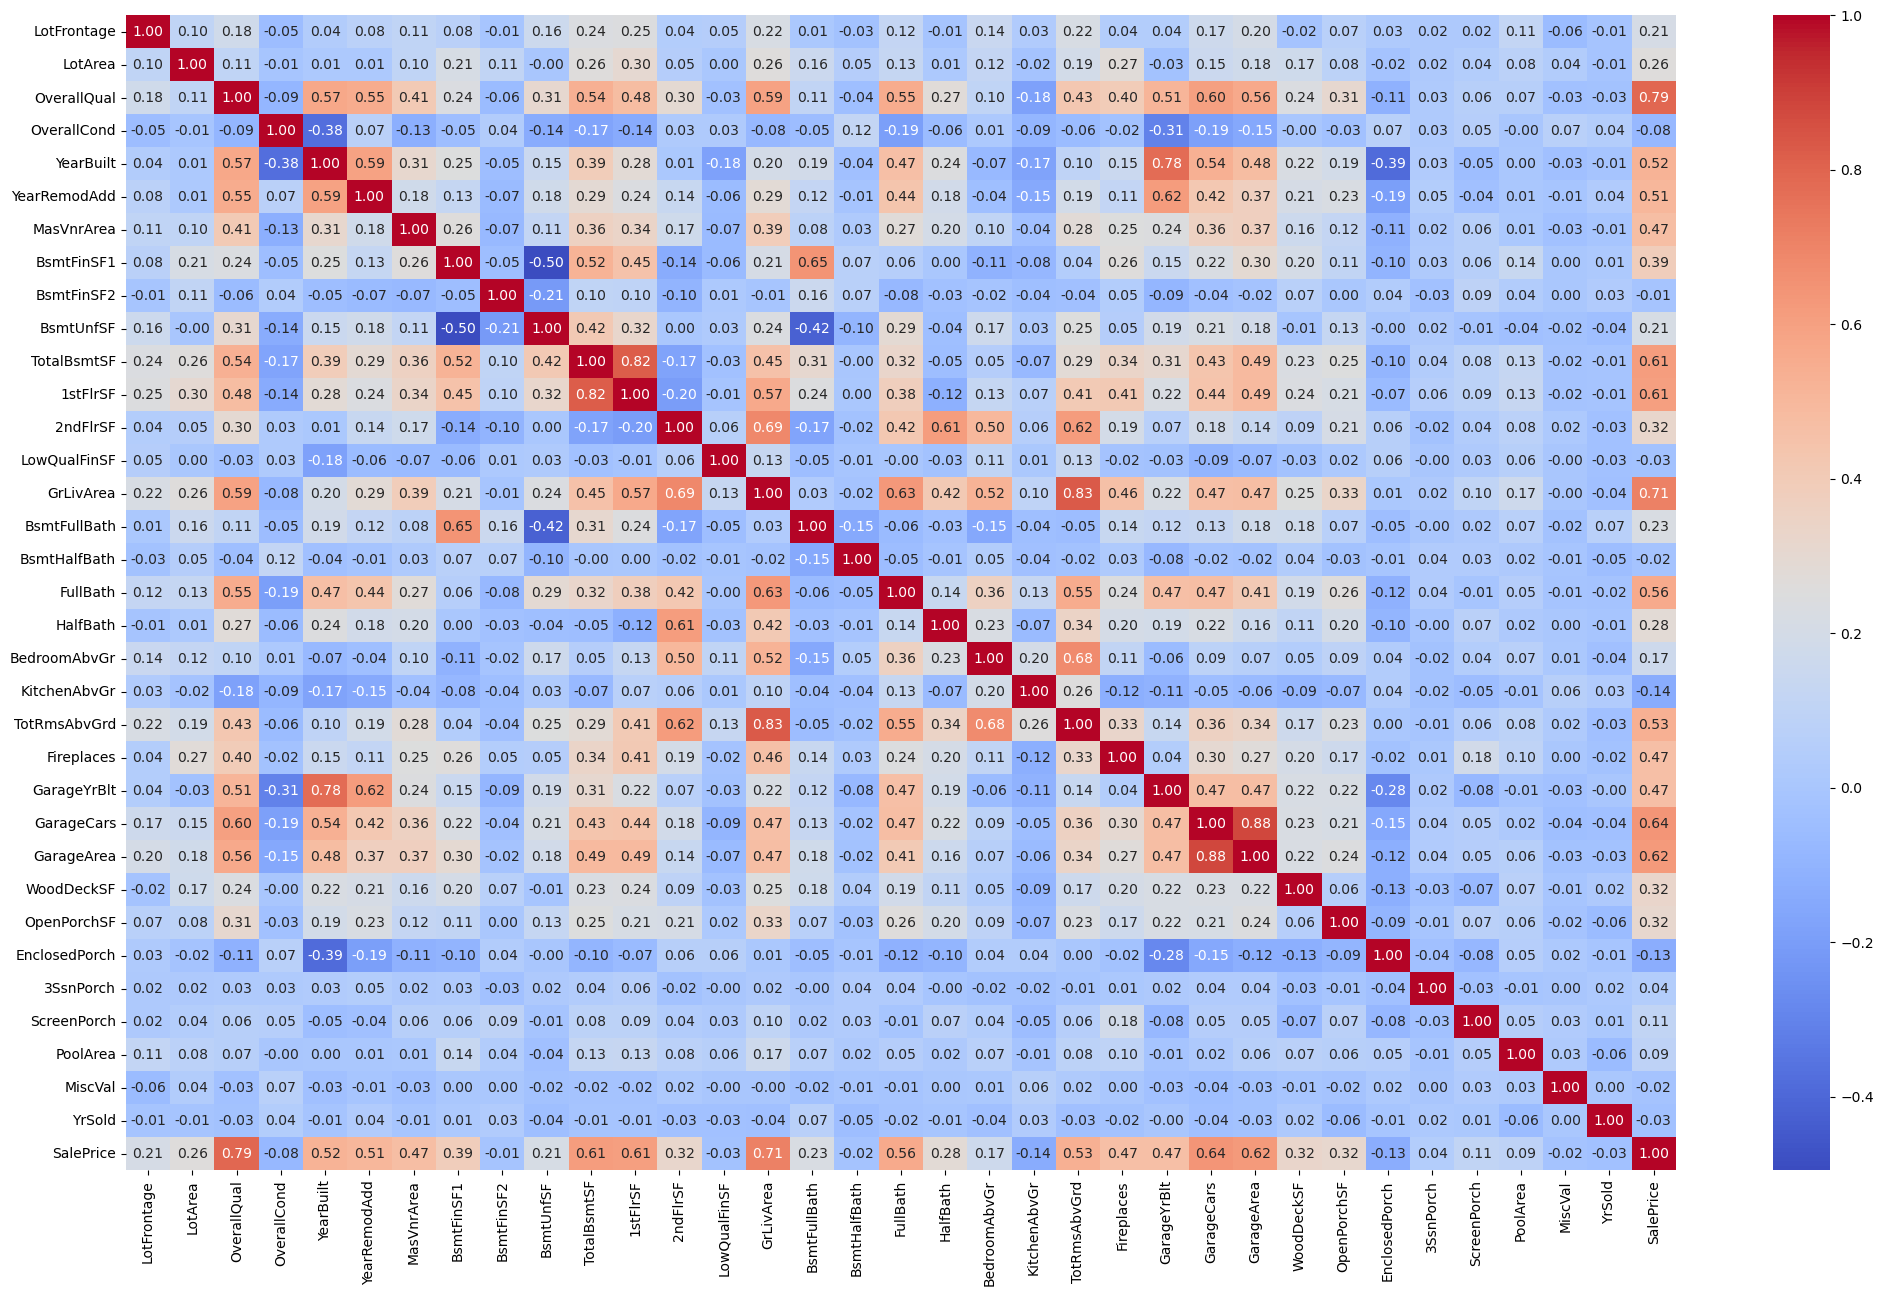

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
MasVnrArea       0.472614
Fireplaces       0.466929
GarageYrBlt      0.466754
BsmtFinSF1       0.386420
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
LotFrontage      0.209624
BedroomAbvGr     0.168213
KitchenAbvGr     0.135907
EnclosedPorch    0.128578
ScreenPorch      0.111447
PoolArea         0.092404
OverallCond      0.077856
3SsnPorch        0.044584
YrSold           0.028923
LowQualFinSF     0.025606
MiscVal          0.021190
BsmtHalfBath     0.016844
BsmtFinSF2       0.011378
Name: SalePrice, dtype: float64


In [153]:
# Checking Correlation of numerical data with SalePrice 
correlation = numerical_data.corr()
plt.figure(figsize=(25, 15))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()
target_corr = correlation["SalePrice"].abs().sort_values(ascending=False)
print(target_corr)

Observation
1) OverallQual-                 Higher-quality houses sell for more.
2) GrLivArea -                  Larger living spaces result in higher prices.
3) GarageCars and GarageArea -  Bigger garages (in size and capacity) increase house value.
4) TotalBsmtSF and 1stFlrSF -   A bigger basement and first floor contribute to higher prices.
5) FullBath and TotRmsAbvGrd -  More rooms and bathrooms increase home value.
6) YearBuilt and YearRemodAdd - Newer houses a recent remodels increase price.
7) MasVnrArea -                 Masonry veneer adds aesthetic/luxury value.
8) Fireplaces -                 Houses with fireplaces tend to be pricier.
9) GarageYrBlt -                Newer garages = higher home value.
10) BsmtFinSF1 -                More finished basement space increases price.
11) WoodDeckSF and OpenPorchSF- Outdoor features add value.
12) 2ndFlrSF -                  Bigger second floors correlate with price. 

# Feature Engineering (Normalisation of Data)

In [157]:
#  Based on the Analysis of housing data, here Separate list of Categorical data columns and Numerical Data columns are created 
# which actual influences the house prices.

In [159]:
categorical_feature = df[['Neighborhood', 'MSZoning', 'LotConfig', 'Foundation', 'ExterQual', 
                       'ExterCond','BsmtQual', 'BsmtCond', 'KitchenQual', 'FireplaceQu', 'PavedDrive','GarageFinish',
                       'GarageQual', 'PoolQC', 'Fence', 'SaleCondition']]

In [161]:
removed_columns = ['HalfBath', 'LotArea' ,'BsmtFullBath', 'BsmtUnfSF', 'LotFrontage', 'BedroomAbvGr', 'KitchenAbvGr', 'EnclosedPorch', 'ScreenPorch', 'PoolArea', 'OverallCond', '3SsnPorch'] 
numerical_feature = numerical_data.drop(df[removed_columns],axis =1)

Explanation
1) Some of the numerical columns are removed to create separate numerical feature list for analysis.
2) Drop removed_columns list of data from numerical_feature which is not too much impactfull for SalePrice

In [164]:
categorical_feature.head(3)

,Neighborhood,MSZoning,LotConfig,Foundation,ExterQual,ExterCond,BsmtQual,BsmtCond,KitchenQual,FireplaceQu,PavedDrive,GarageFinish,GarageQual,PoolQC,Fence,SaleCondition
0,CollgCr,RL,Inside,PConc,Gd,TA,Gd,TA,Gd,No,Y,RFn,TA,No,No,Normal
1,Veenker,RL,FR2,CBlock,TA,TA,Gd,TA,TA,TA,Y,RFn,TA,No,No,Normal
2,CollgCr,RL,Inside,PConc,Gd,TA,Gd,TA,Gd,TA,Y,RFn,TA,No,No,Normal


In [166]:
categorical_feature.shape

(1460, 16)

In [168]:
numerical_feature.head(3)

,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,...,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,MiscVal,YrSold,SalePrice
0,7,2003,2003,196,706,0,856,856,854,0,...,8,0,2003.0,2,548,0,61,0,2008,208500
1,6,1976,1976,0,978,0,1262,1262,0,0,...,6,1,1976.0,2,460,298,0,0,2007,181500
2,7,2001,2002,162,486,0,920,920,866,0,...,6,1,2001.0,2,608,0,42,0,2008,223500


In [170]:
numerical_feature.shape

(1460, 23)

In [172]:
# concatenating categorical_feature and numerical_feature to create combined dataset
df1 = pd.concat([categorical_feature,numerical_feature], axis = 1)
df1.head()

,Neighborhood,MSZoning,LotConfig,Foundation,ExterQual,ExterCond,BsmtQual,BsmtCond,KitchenQual,FireplaceQu,...,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,MiscVal,YrSold,SalePrice
0,CollgCr,RL,Inside,PConc,Gd,TA,Gd,TA,Gd,No,...,8,0,2003.0,2,548,0,61,0,2008,208500
1,Veenker,RL,FR2,CBlock,TA,TA,Gd,TA,TA,TA,...,6,1,1976.0,2,460,298,0,0,2007,181500
2,CollgCr,RL,Inside,PConc,Gd,TA,Gd,TA,Gd,TA,...,6,1,2001.0,2,608,0,42,0,2008,223500
3,Crawfor,RL,Corner,BrkTil,TA,TA,TA,Gd,Gd,Gd,...,7,1,1998.0,3,642,0,35,0,2006,140000
4,NoRidge,RL,FR2,PConc,Gd,TA,Gd,TA,Gd,TA,...,9,1,2000.0,3,836,192,84,0,2008,250000


In [174]:
# check Total number of new rows and columns
df1.shape

(1460, 39)

Columns are reduced from 80 to 39

In [177]:
#  So first here we are seprating dataset into feature and target
X = df1.drop(columns = ['SalePrice'])
y = df1['SalePrice']

In [179]:
# Import packages for Scalling 
from sklearn.preprocessing import StandardScaler

In [181]:
# Access all numerical feature from feature data and store in one veriable
# fit and transform the data into StandardScaler
num_col = X.select_dtypes(include=['int64', 'float64']).columns
scalled_data = StandardScaler().fit_transform(X[num_col])
scalled_data

array([[ 0.65147924,  1.05099379,  0.87866809, ...,  0.21650316,
        -0.08768781,  0.13877749],
       [-0.07183611,  0.15673371, -0.42957697, ..., -0.70448325,
        -0.08768781, -0.61443862],
       [ 0.65147924,  0.9847523 ,  0.83021457, ..., -0.07036146,
        -0.08768781,  0.13877749],
       ...,
       [ 0.65147924, -1.00249232,  1.02402865, ...,  0.20140502,
         4.95311151,  1.64520971],
       [-0.79515147, -0.70440562,  0.53949344, ..., -0.70448325,
        -0.08768781,  1.64520971],
       [-0.79515147, -0.20759447, -0.96256569, ...,  0.32219013,
        -0.08768781,  0.13877749]])

In [183]:
# Import packages for Encoding and ColumnTransformer 
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

# Defining Ordinal and nominal categorical columns
ordinal_col = ['ExterQual','ExterCond','BsmtQual','BsmtCond','KitchenQual','FireplaceQu','GarageQual','PoolQC']

# Define order for ordinal columns
ordinal_category = [['Ex','Gd','TA','Fa','Po'],['Ex','Gd','TA','Fa','Po'],['Ex','Gd','TA','Fa','No'],['Gd','TA','Fa','Po','No'],
                    ['Ex','Gd','TA','Fa'], ['Ex','Gd','TA','Fa','Po','No'],['Ex','Gd','TA','Fa','Po','No'],['Ex','Gd','Fa','No']]

nominal_col = ['Neighborhood','MSZoning','LotConfig','Foundation','PavedDrive','GarageFinish','Fence','SaleCondition']

# Defining the Column Transformer and Encode ordinal and nominal categorical features
preprocess = ColumnTransformer([
    ('ordinal', OrdinalEncoder(categories = ordinal_category), ordinal_col), 
    ('nominal', OneHotEncoder(handle_unknown='ignore'), nominal_col)], remainder='passthrough')

#  Scale Target
target_scaled = ColumnTransformer([('target_scaled', StandardScaler(), ['SalePrice'])])  

#Transform Features & Target, but b4 target data 'y'(SalePrice) causing issues, Converted it to a DataFrame before scaling.
y = pd.DataFrame(y, columns=['SalePrice'])
X_preprocess = preprocess.fit_transform(X)
y_scaled = target_scaled.fit_transform(y)

In [185]:
# Now data is ready for training and testing to fit in machine learning model.

In [187]:
X_preprocess

array([[1.000e+00, 2.000e+00, 1.000e+00, ..., 6.100e+01, 0.000e+00,
        2.008e+03],
       [2.000e+00, 2.000e+00, 1.000e+00, ..., 0.000e+00, 0.000e+00,
        2.007e+03],
       [1.000e+00, 2.000e+00, 1.000e+00, ..., 4.200e+01, 0.000e+00,
        2.008e+03],
       ...,
       [0.000e+00, 1.000e+00, 2.000e+00, ..., 6.000e+01, 2.500e+03,
        2.010e+03],
       [2.000e+00, 2.000e+00, 2.000e+00, ..., 0.000e+00, 0.000e+00,
        2.010e+03],
       [1.000e+00, 2.000e+00, 2.000e+00, ..., 6.800e+01, 0.000e+00,
        2.008e+03]])

In [189]:
y_scaled

array([[ 0.34727322],
       [ 0.00728832],
       [ 0.53615372],
       ...,
       [ 1.07761115],
       [-0.48852299],
       [-0.42084081]])

# Conclusion

In [ ]:
# 1) Superior Construction & Contemporary Finishes (Overall Quality):> Homebuyers choose well-constructed residences with premium components.Desirability is raised by updated kitchens, contemporary bathrooms, and high-end flooring.

# 2) Generous Living Spaces (FirstFlrSF, TotalBsmtSF, GrLivArea) :> There is a strong desire for larger homes with open floor layouts and lots of living space. Finished basements increase value by adding useful space.

# 3) Garage & Parking Space (GarageCars, GarageAr>ea): Larger garages are preferred by buyers for storage and parking. Attached garages are very popular in suburban and urban settings.

# 4) Outdoor Features (OpenPorchSF, WoodDe>ckSF): Patios, porches, and decks add attractiveness to a home's lifestyle, particularly in suburban settings. Homes with private outside areas are preferred by buyer.

# 5) Extra Comfort Features (Fireplaces, FullBath, TotRmsAbvGrd>): Fireplaces are regarded as a luxury feature that enhances cosiness and increases the value of a home when it is sold. Homes with more rooms and complete bathrooms are more useful for families.

# 6) Renovations & Modernisation (YearRemodAdd, YearBuilt) :> Recently remodelled and newer homes sell more quickly and for more money. Smart house features, energy-efficient systems, and renovated kitchens are prefered by buyer.

# 7) Lot and Location Factors (Lot Frontage, Lot Area):> Although lot size matters, purchasers frequently give location a higher priority than land acreage. More essential than having a large garden is being close to amenties, school and playing yard.